# Projet H2026 : Prédiction de la quantité de particules fines dans l'air de Montréal

Présenté par:
- Camil Bisson (2277718)
- Charles-Francis Damedey (2141785)
- Wilfred Poirier (2270349)
- Timothy Lau (2293503) 
- Yanis Kadri (1946507)


## 1. Introduction

### Contexte du projet

La Ville de Montréal mesure la qualité de l’air sous la forme d’une valeur numérique appelée « indice de la qualité de l’air » (IQA). La valeur 50 de cet indice correspond à la limite supérieure acceptable pour chacun des polluants mesurés. Les particules fines (PM, pour matière particulaire) correspondent aux particules en suspension dans l'atmosphère (aérosols). Un grand taux de ces particules dans l'air peut entraîner des risques potentiels pour la santé, en particulier pour les enfants, les personnes âgées ou asthmatiques.

Vous avez accès aux données de qualité de l'air de différentes stations de l'île de Montréal, soit :
- Saint-Joseph,
- Saint-Jean-Baptiste,
- Aéroport de Montréal,
- Caserne 17,
- York/Roberval,
- Saint-Dominique et
- Anjou.

**But** : Prédire l'IQA des particules fines (PM) dans l'air de Montréal au cours de l'année 2025.

### Données disponibles

Dans un premier temps, nous avons accédé aux fichiers suivants sur la plateforme Kaggle:
- qualite-de-lair_train.csv
- meteo_train.csv
- qualite-de-lair_test.csv
- meteo_test.csv

Le fichier *qualite-de-lair_train.csv* contient l'IQA des sept stations de Montréal entre 2007 et 2024 (inclusivement). Voici la description des colonnes :

- stationId : Identifiant de la station
- nom : Nom de la station
- latitude : Latitude de la station
- longitude : Longitude de la station
- Élévation : Élévation de la station
- Date : Date de la mesure
- PM : IQA pour les particules fines
- O3 : IQA pour l'ozone
- NO2 : IQA pour le dioxyde d'azote
- SO2 : IQA pour le dioxyde de soufre

Le fichier *meteo_train.csv* contient diverses observations météorologiques de la station de l'aéroport de Montréal pour les mêmes années que *qualite-de-lair_train.csv*. Voici la description des colonnes :

- latitude : Latitude de la station
- longitude : Longitude de la station
- Date : Date de la mesure
- pluie : Quantité totale de pluie tombée au cours de la journée (en mm)
- neige : Quantité totale de neige tombée au cours de la journée (en cm)
- precip_tot : Quantité totale de précipitations tombées au cours de la journée (en mm, conversion de la neige en eau liquide)
- neige_au_sol : Quantité de neige au sol (en cm)
- hum_rel (max, min et moy) : humidité relative maximum, minimum et moyenne de la journée (en %)
- pt_rosee : Point de rosée moyen de la journée (en °C)
- vitesse_vent (max, min et moy) : Vitesse maximum, minimum et moyenne du vent au cours de la journée (en km/h)
- visibilite (max, min et moy) : Visibilité maximum, minimum et moyenne de la journée (en km)
- pression (max, min et moy) : Pression maximum, minimum et moyenne de la journée (en kPa)
- temp (max, min et moy) : Température maximum, minimumm et moyenne de la journée (en °C)

Les fichiers *qualite-de-lair_test.csv* et *meteo_test.csv* contiennent les observations de toutes les variables précédemment mentionnées (sauf PM!) pour les 365 jours de 2025. Nous devons prédire l'IQA des particules fines pour l'ensemble des stations (7) et des jours de 2025 (365), ce qui fait un total de 2555 valeurs à prédire ($7\times365$).

## 2. Chargement et nettoyage des données

In [53]:
using CSV, DataFrames, Dates, Statistics, Plots, Gadfly, CategoricalArrays, GLM, LinearAlgebra

In [54]:
air_train_raw = CSV.read("data/qualite-de-lair_train.csv", DataFrame)
meteo_train_raw = CSV.read("data/meteo_train.csv", DataFrame)

air_test_raw = CSV.read("data/qualite-de-lair_test.csv", DataFrame)
meteo_test_raw = CSV.read("data/meteo_test.csv", DataFrame)

Row,longitude,latitude,Date,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy
,Float64,Float64,Date,Float64?,Float64?,Float64?,Int64?,Int64,Int64,Float64,Float64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,-73.74,45.47,2025-01-01,1.2,5.6,6.8,0,97,81,91.75,-0.25,26,8,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333
2,-73.74,45.47,2025-01-02,0.0,0.0,0.0,0,88,65,73.0,-5.50833,48,30,37.375,24.1,6.4,20.6958,100.09,99.2,99.7404,1.2,-3.4,-1.225
3,-73.74,45.47,2025-01-03,0.0,0.4,0.4,0,78,59,64.7917,-11.4125,36,20,28.125,48.3,3.2,25.2583,100.16,99.94,100.078,-3.7,-9.5,-5.76667
4,-73.74,45.47,2025-01-04,0.0,0.8,0.8,0,84,57,70.4167,-15.1208,35,11,23.5,24.1,2.4,11.85,100.51,100.04,100.312,-9.4,-12.4,-10.6917
5,-73.74,45.47,2025-01-05,0.2,0.0,0.2,1,86,49,59.9167,-18.3708,26,8,17.125,48.3,0.8,23.6708,101.57,100.5,101.076,-9.5,-13.0,-11.8958
6,-73.74,45.47,2025-01-06,0.0,0.4,0.4,1,73,59,67.9167,-17.1542,23,8,14.1667,24.1,24.1,24.1,101.56,100.35,101.006,-9.8,-15.1,-12.3667
7,-73.74,45.47,2025-01-07,0.0,4.0,4.0,2,84,60,73.25,-12.5208,33,19,25.8333,19.3,2.0,9.0,100.85,100.09,100.375,-6.5,-10.3,-8.47083
8,-73.74,45.47,2025-01-08,0.0,3.6,3.6,2,80,65,74.2917,-16.3083,33,19,27.5417,16.1,1.6,8.675,100.86,100.2,100.578,-10.7,-14.3,-12.6167
9,-73.74,45.47,2025-01-09,0.0,0.6,0.6,2,79,63,70.5417,-13.7083,33,20,27.25,24.1,4.0,20.725,100.91,100.17,100.466,-6.2,-11.9,-9.2625


### Imputation des données météorologiques manquantes

Lors de l'inspection préliminaire des données, nous avons d'abord observé un cas particulièrement anormal dans le fichier `meteo_train.csv` : la date du `2013-02-14` apparaît 32 fois. Ces lignes présentent de nombreuses valeurs manquantes pour les variables liées aux précipitations et combinent plusieurs valeurs répétées pour d'autres variables météorologiques, ce qui suggère une anomalie importante dans les données.

In [55]:
dup_dates = combine(groupby(meteo_train_raw, :Date), nrow => :n)
dup_dates = filter(:n => >(1), dup_dates)

first(sort(dup_dates, :n, rev = true), 10)

Row,Date,n
,Date,Int64
1,2013-02-14,32
2,2013-01-01,2
3,2013-01-02,2
4,2013-01-03,2
5,2013-01-04,2
6,2013-01-05,2
7,2013-01-06,2
8,2013-01-07,2
9,2013-01-08,2


Comme cette journée est isolée et que sa structure est manifestement incohérente, nous choisissons de la retirer complètement de l'ensemble météorologique avant de poursuivre le nettoyage.

In [56]:
date_anormale = Date("2013-02-14")
meteo_train_filtered = filter(:Date => !=(date_anormale), meteo_train_raw)

println("Taille avant retrait du 2013-02-14 : ", nrow(meteo_train_raw), " lignes et ", ncol(meteo_train_raw), " colonnes")
println("Taille après retrait du 2013-02-14 : ", nrow(meteo_train_filtered), " lignes et ", ncol(meteo_train_filtered), " colonnes")

Taille avant retrait du 2013-02-14 : 6967 lignes et 23 colonnes
Taille après retrait du 2013-02-14 : 6935 lignes et 23 colonnes


Au-delà de cette date anormale, le fichier `meteo_train.csv` contient aussi plusieurs dates dupliquées, en particulier pour l'année 2013. Pour une même date, certaines lignes sont pratiquement identiques, sauf que l'une d'entre elles contient des valeurs manquantes pour les variables liées aux précipitations (`pluie`, `neige`, `precip_tot`). Comme ces duplications faussent la jointure avec les données de qualité de l'air, nous commençons par une première étape de déduplication : lorsqu'une date apparaît plus d'une fois, nous conservons la ligne qui contient le plus d'information sur les précipitations.

In [57]:
precip_cols = [:pluie, :neige, :precip_tot]
function deduplicate_meteo_by_date(df::DataFrame)
    combine(groupby(df, :Date)) do sdf
        scores = [count(x -> !ismissing(x), row[precip_cols]) for row in eachrow(sdf)]
        sdf[argmax(scores), :]
    end
end

dup_dates_filtered = combine(groupby(meteo_train_filtered, :Date), nrow => :n)
dup_dates_filtered = filter(:n => >(1), dup_dates_filtered)

println("Nombre de dates dupliquées dans meteo_train_filtered : ", nrow(dup_dates_filtered))

meteo_train = sort(deduplicate_meteo_by_date(meteo_train_filtered), :Date)
meteo_test = sort(deduplicate_meteo_by_date(meteo_test_raw), :Date)

println("Taille avant déduplication (train) : ", nrow(meteo_train_filtered), " lignes et ", ncol(meteo_train_filtered), " colonnes")
println("Taille après déduplication (train) : ", nrow(meteo_train), " lignes et ", ncol(meteo_train), " colonnes")
println("Taille avant déduplication (test)  : ", nrow(meteo_test_raw), " lignes et ", ncol(meteo_test_raw), " colonnes")
println("Taille après déduplication (test)  : ", nrow(meteo_test), " lignes et ", ncol(meteo_test), " colonnes")

Nombre de dates dupliquées dans meteo_train_filtered : 361
Taille avant déduplication (train) : 6935 lignes et 23 colonnes
Taille après déduplication (train) : 6574 lignes et 23 colonnes
Taille avant déduplication (test)  : 365 lignes et 23 colonnes
Taille après déduplication (test)  : 365 lignes et 23 colonnes


Dans un deuxième temps, nous traitons les valeurs manquantes restantes avec une règle uniforme pour toutes les variables météo retenues. Lorsqu'un trou compte seulement `1` ou `2` jours consécutifs et qu'il est encadré par deux valeurs observées, nous utilisons une interpolation linéaire. Par exemple, `1, missing, 3` devient `1, 2, 3`, et `1, missing, missing, 4` devient `1, 2, 3, 4`.

Nous limitons l'interpolation linéaire aux séquences de 1 ou 2 jours afin d'éviter de reconstruire artificiellement de longues périodes
météorologiques absentes. Sur une courte fenêtre, les variables météo évoluent généralement de façon relativement continue, ce qui rend cette
approximation acceptable.

En revanche, dès qu'une séquence manquante atteint `3` jours ou plus, ou qu'elle se situe au début ou à la fin de la série et ne peut donc pas être interpolée proprement, nous la remplaçons par `0`. Cette règle vise à limiter les imputations trop agressives tout en supprimant les valeurs manquantes restantes.

In [58]:
meteo_interp_cols = [:pluie, :neige, :precip_tot, :neige_au_sol]

function interpolate_missing_linear!(df::DataFrame, cols::Vector{Symbol})
    sort!(df, :Date)

    for col in cols
        values = Union{Missing, Float64}[ismissing(x) ? missing : Float64(x) for x in df[!, col]]
        i = 1

        while i <= length(values)
            if !ismissing(values[i])
                i += 1
                continue
            end

            start_idx = i
            while i <= length(values) && ismissing(values[i])
                i += 1
            end
            end_idx = i - 1
            gap = end_idx - start_idx + 1

            left_idx = start_idx - 1
            right_idx = i <= length(values) ? i : nothing

            if gap <= 2 && left_idx >= 1 && !ismissing(values[left_idx]) && !isnothing(right_idx) && !ismissing(values[right_idx])
                left_val = values[left_idx]
                right_val = values[right_idx]
                step = (right_val - left_val) / (gap + 1)

                for k in 1:gap
                    values[start_idx + k - 1] = left_val + step * k
                end
            else
                values[start_idx:end_idx] .= 0.0
            end
        end

        df[!, col] = values
    end

    df
end

function summarize_missing(before_df::DataFrame, after_df::DataFrame, cols::Vector{Symbol}, dataset_name::AbstractString)
    DataFrame(
        jeu_de_donnees = fill(dataset_name, length(cols)),
        variable = string.(cols),
        manquants_avant = [count(ismissing, before_df[!, col]) for col in cols],
        manquants_apres = [count(ismissing, after_df[!, col]) for col in cols]
    )
end

meteo_train_before = copy(meteo_train)
meteo_test_before = copy(meteo_test)

interpolate_missing_linear!(meteo_train, meteo_interp_cols)
interpolate_missing_linear!(meteo_test, meteo_interp_cols)

vcat(
    summarize_missing(meteo_train_before, meteo_train, meteo_interp_cols, "meteo_train"),
    summarize_missing(meteo_test_before, meteo_test, meteo_interp_cols, "meteo_test")
)

Row,jeu_de_donnees,variable,manquants_avant,manquants_apres
,String,String,Int64,Int64
1,meteo_train,pluie,67,0
2,meteo_train,neige,53,0
3,meteo_train,precip_tot,56,0
4,meteo_train,neige_au_sol,3014,0
5,meteo_test,pluie,2,0
6,meteo_test,neige,1,0
7,meteo_test,precip_tot,2,0
8,meteo_test,neige_au_sol,227,0


### Imputation des données de qualité de l'air manquantes

Comme plusieurs stations mesurent les polluants pour une même journée, il est possible d'utiliser l'information disponible aux autres stations afin d'estimer une valeur absente.

L'idée retenue est la suivante : lorsqu'une valeur est manquante pour une station à une date donnée, nous la remplaçons par la moyenne des valeurs observées aux autres stations pour cette même date. Cette approche est simple, cohérente avec la structure des données, et constitue donc un premier nettoyage naturel à tester.

In [59]:
air_train_cols = [:PM, :O3, :NO2, :SO2]
air_test_cols = [:O3, :NO2, :SO2]

function impute_missing_by_daily_station_mean(df::DataFrame, cols::Vector{Symbol})
    df_clean = copy(df)

    for col in cols
        transform!(groupby(df_clean, :Date),
            col => (x -> all(ismissing, x) ? fill(missing, length(x)) : coalesce.(x, mean(skipmissing(x)))) => col)
    end

    sort!(df_clean, [:Date, :stationId])
    df_clean
end

air_train = impute_missing_by_daily_station_mean(air_train_raw, air_train_cols)
air_test = impute_missing_by_daily_station_mean(air_test_raw, air_test_cols)

vcat(
    summarize_missing(air_train_raw, air_train, air_train_cols, "air_train"),
    summarize_missing(air_test_raw, air_test, air_test_cols, "air_test")
)

Row,jeu_de_donnees,variable,manquants_avant,manquants_apres
,String,String,Int64,Int64
1,air_train,PM,821,0
2,air_train,O3,477,0
3,air_train,NO2,1013,1
4,air_train,SO2,14243,4
5,air_test,O3,17,0
6,air_test,NO2,346,0
7,air_test,SO2,1095,0


Après cette étape d'imputation, il peut subsister quelques valeurs manquantes résiduelles. La raison est simple : pour certaines dates, aucune autre station ne fournit une valeur exploitable pour le polluant concerné. Autrement dit, lorsqu'une variable est absente pour toutes les stations disponibles à une même date, la moyenne journalière ne peut pas être calculée et l'imputation devient impossible.

Comme ces cas restent très rares, nous choisissons simplement de retirer les lignes résiduelles concernées dans les jeux de données sur la qualité de l'air.

In [60]:
air_train = dropmissing(air_train, air_train_cols)
air_test = dropmissing(air_test, air_test_cols)

println("Taille finale de air_train : ", nrow(air_train), " lignes et ", ncol(air_train), " colonnes")
println("Taille finale de air_test : ", nrow(air_test), " lignes et ", ncol(air_test), " colonnes")

Taille finale de air_train : 31677 lignes et 10 colonnes
Taille finale de air_test : 2555 lignes et 9 colonnes


À ce stade, les jeux de données nettoyés ne contiennent plus de valeurs manquantes dans les variables conservées pour l'analyse.

In [61]:
DataFrame(
    jeu_de_donnees = ["air_train", "meteo_train", "air_test", "meteo_test"],
    n_manquants = [
        sum(count(ismissing, col) for col in eachcol(air_train)),
        sum(count(ismissing, col) for col in eachcol(meteo_train)),
        sum(count(ismissing, col) for col in eachcol(air_test)),
        sum(count(ismissing, col) for col in eachcol(meteo_test))
    ]
)

Row,jeu_de_donnees,n_manquants
,String,Int64
1,air_train,0
2,meteo_train,0
3,air_test,0
4,meteo_test,0


### Jointure des données en un seul jeu de données

Une fois les données manquantes imputées, nous construisons le jeu d'entraînement final en effectuant une jointure interne entre `air_train` et `meteo_train` sur la variable `Date`. Cette jointure associe à chaque observation de qualité de l'air les conditions météorologiques du même jour, tout en ne conservant que les dates présentes dans les deux tables.

Avant la jointure, nous retirons les colonnes `latitude` et `longitude` du jeu météo afin d'éviter les doublons de noms, puisque les coordonnées des stations sont déjà présentes dans `air_train`.

In [62]:
meteo_train_for_join = select(meteo_train, Not([:latitude, :longitude]))
train_joined = innerjoin(air_train, meteo_train_for_join, on = :Date)
meteo_test_for_join = select(meteo_test, Not([:latitude, :longitude]))
test_joined = innerjoin(air_test, meteo_test_for_join, on = :Date)

println("Nombre de lignes dans train_joined : ", nrow(train_joined))
first(train_joined, 10)

Nombre de lignes dans train_joined : 31674


Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy
,Int64,String31,Float64,Float64,Int64,Date,Real,Real,Real,Real,Float64?,Float64?,Float64?,Float64?,Int64,Int64,Float64,Float64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-01,33,19,7,11,10.6,0.0,10.6,9.0,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775
2,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-01,9,18,6,11.0,10.6,0.0,10.6,9.0,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775
3,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-02,14,22,7,11,0.0,0.0,0.0,0.0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167
4,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-02,5,22,5,11.0,0.0,0.0,0.0,0.0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167
5,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-03,25,11,7,13,0.0,0.0,0.0,0.0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833
6,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-03,12,16,6,13.0,0.0,0.0,0.0,0.0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833
7,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-04,25,9,8,15,0.6,0.0,0.6,0.0,80,58,69.5833,0.375,22,0,13.5,48.3,24.1,26.6792,101.09,100.55,100.906,9.6,1.4,5.55
8,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-04,21,12,9,15.0,0.6,0.0,0.6,0.0,80,58,69.5833,0.375,22,0,13.5,48.3,24.1,26.6792,101.09,100.55,100.906,9.6,1.4,5.55
9,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-05,23,7,7,9,14.2,0.0,14.2,0.0,100,75,96.4167,6.625,17,4,10.7917,25.0,1.2,7.66667,100.57,100.09,100.314,9.7,4.6,7.17917


### Traitement des données aberrantes

#### Identification
Notre première tentative consistait à calculer le **score z** classique de chaque variable quantitative par rapport à sa moyenne globale.

$$z_i = \frac{|x_i - \mu|}{\sigma}$$

Dans cette formule, $x_i$ représente la valeur observée pour l'observation $i$, $\mu$ représente la moyenne globale de la variable étudiée, et $\sigma$ représente son écart-type global. Le score $z_i$ mesure donc l'ampleur de l'écart entre l'observation $x_i$ et la moyenne, exprimée en nombre d'écarts-types.

Cependant, cette approche s'est révélée peu adaptée à notre problème, car une observation extrême contribue elle-même au calcul de la moyenne et de l'écart-type de sa variable. Elle peut donc atténuer artificiellement son propre écart à la distribution globale, ce qui rend l'identification des valeurs aberrantes moins fiable.

Ces seuils suivent une règle empirique courante : une observation située à moins de deux écarts-types de la référence est généralement considérée normale, entre deux et trois écarts-types elle est inhabituelle, et au-delà de trois écarts-types elle est considérée comme fortement atypique.

| Intervalle | Interprétation |
|------------|----------------|
| $0 \leq z_i \leq 2$ | Normal |
| $2 \leq z_i \leq 3$ | Modérément anormal |
| $z_i > 3$ | Anormal, donnée aberrante |

Ces seuils donnent une première règle de détection, mais ils doivent être adaptés au contexte des stations de mesure. Nous voulons surtout repérer une station qui s'écarte fortement des autres stations observées la même journée, plutôt qu'une valeur simplement éloignée de la distribution globale.

Pour contourner cette difficulté, nous retenons plutôt le **score z leave-one-out (LOO)**, appliqué séparément à chaque variable quantitative. Cette mesure compare une observation aux autres stations observées la même journée, en excluant l'observation évaluée du calcul de la moyenne et de l'écart-type.

$$z_i^{\text{LOO}} = \frac{|x_i - \mu_{-i}|}{\sigma_{-i}}$$

Ici, $\mu_{-i}$ et $\sigma_{-i}$ désignent la moyenne et l'écart-type calculés **sans** l'observation $x_i$. La valeur absolue est utilisée afin de mesurer l'ampleur de l'écart sans tenir compte de sa direction. Cette mesure est plus pertinente dans notre contexte, car elle permet d'identifier, pour chaque variable, une station dont la valeur s'écarte fortement de celles des autres stations à une même date.

In [63]:
# Calcule le score z leave-one-out pour une variable donnée.
function calculer_zloo(df::DataFrame, col_name::Symbol)
    # On conserve seulement les colonnes nécessaires au calcul.
    df_res = select(df, :Date, :stationId, col_name)
    df_valid = dropmissing(df_res, col_name)
    
    n_rows  = nrow(df_res)
    zscores = Vector{Union{Missing, Float64}}(missing, n_rows)
    mu_loo  = Vector{Union{Missing, Float64}}(missing, n_rows)
    sig_loo = Vector{Union{Missing, Float64}}(missing, n_rows)

    # Si la variable ne contient aucune valeur observée, les statistiques restent manquantes.
    if nrow(df_valid) == 0
        df_res[!, :mu_loo] = mu_loo
        df_res[!, :sigma_loo] = sig_loo
        df_res[!, :zscore_loo] = zscores
        return df_res
    end
    
    # Agrégations temporelles (Σx, Σx², N)
    daily_stats = combine(groupby(df_valid, :Date),
        col_name => sum              => :Σx,
        col_name => (x -> sum(x.^2)) => :Σx²,
        col_name => length           => :N
    )
    
    # Dictionnaire pour accès O(1) sans perturber l'ordre initial.
    dict_stats = Dict(row.Date => (row.Σx, row.Σx², row.N) for row in eachrow(daily_stats))
    
    for i in 1:n_rows
        x = df_res[i, col_name]
        d = df_res[i, :Date]
        
        if ismissing(x) || !haskey(dict_stats, d)
            continue
        end
        
        Σx, Σx², N = dict_stats[d]
        
        if N < 2
            continue
        end
        
        # Application formule LOO
        μ = (Σx - x) / (N - 1)
        mu_loo[i] = μ
        
        if N < 3
            sig_loo[i] = 0.0
            zscores[i] = 0.0
        else
            var_o = max(0.0, (Σx² - x^2 - (Σx - x)^2 / (N - 1)) / (N - 2))
            σ = sqrt(var_o)
            sig_loo[i] = σ
            zscores[i] = σ > 0 ? abs(x - μ) / σ : 0.0
        end
    end
    
    df_res[!, :mu_loo] = mu_loo
    df_res[!, :sigma_loo] = sig_loo
    df_res[!, :zscore_loo] = zscores
    return df_res
end


calculer_zloo (generic function with 1 method)

#### Validation manuelle
La cellule suivante permet d'inspecter manuellement les observations les plus extrêmes détectées par le score z LOO pour quelques variables d'intérêt. Elle ne modifie pas les données : elle sert uniquement à vérifier si les écarts repérés paraissent plausibles au regard des valeurs observées dans les autres stations à la même date.

In [64]:
# Poluants à analyser
polluants_cibles = [:PM, :O3, :NO2, :SO2]

for col_sym in polluants_cibles
    println("\nValeurs les plus extrêmes selon le score z LOO pour la variable : ", String(col_sym))
    
    # 1. Calcul des statistiques LOO sur les données originales 
    df_stats = calculer_zloo(train_joined, col_sym)
    
    # 2. Ramener le nom des stations pour une lecture plus facile
    # On fait un leftjoin en s'assurant de ne pas dupliquer la colonne cible
    noms_stations = select(train_joined, :Date, :stationId, :nom)
    df_stats = leftjoin(df_stats, noms_stations, on=[:Date, :stationId])
    
    # 3. Trier par zscore_loo décroissant (plus grand au plus petit) et extraire les 20 premiers
    df_sorted = sort(dropmissing(df_stats, :zscore_loo), :zscore_loo, rev=true)
    top_20 = first(df_sorted, 20)
    
    # 4. Itérer sur chaque ligne du Top 20 pour construire le rapport 
    for (i, row) in enumerate(eachrow(top_20))
        d = row[:Date]
        stat_id = row[:stationId]
        val_outlier = row[col_sym]
        z_score = round(row[:zscore_loo], digits=2)
        nom_station = row[:nom]
        
        # Trouver les données enregistrées par les autres stations à cette même date exacte
        autres_lignes = train_joined[(train_joined.Date .== d) .& (train_joined.stationId .!= stat_id), col_sym]
        
        # On nettoie pour exclure d'éventuelles données manquantes
        autres_valeurs_propres = collect(skipmissing(autres_lignes))
        
        # Formatage des valeurs des autres stations
        autres_str = join(round.(autres_valeurs_propres, digits=1), ", ")
        
        # Mise en page
        println("#$i | Date : $d | Station : $nom_station (ID: $stat_id)")
        println("      Z-Score LOO                  : $z_score")
        println("      Valeur Aberrante Observée    : $val_outlier")
        println("      Valeurs des autres stations  : [ $autres_str ]")
        println("-"^80)
    end
end



Valeurs les plus extrêmes selon le score z LOO pour la variable : PM
#1 | Date : 2016-11-23 | Station : Saint-Dominique (ID: 31)
      Z-Score LOO                  : 157.22
      Valeur Aberrante Observée    : 296
      Valeurs des autres stations  : [ 10.0, 11.0, 8.0, 10.0, 13.0 ]
--------------------------------------------------------------------------------
#2 | Date : 2024-04-25 | Station : Caserne 17 (ID: 17)
      Z-Score LOO                  : 72.12
      Valeur Aberrante Observée    : 48
      Valeurs des autres stations  : [ 8.0, 8.0, 9.0, 9.0, 8.0, 9.0 ]
--------------------------------------------------------------------------------
#3 | Date : 2009-01-14 | Station : Aéroport de Montréal (ID: 66)
      Z-Score LOO                  : 68.59
      Valeur Aberrante Observée    : 701
      Valeurs des autres stations  : [ 29.0, 15.0 ]
--------------------------------------------------------------------------------
#4 | Date : 2018-07-21 | Station : Saint-Joseph (ID: 80)
      Z

#### Traitement
Une fois les valeurs aberrantes identifiées, plusieurs stratégies de traitement étaient possibles. Remplacer systématiquement une observation extrême par la moyenne des autres stations aurait toutefois eu pour effet de lisser excessivement les données et de faire disparaître une information potentiellement réelle. En effet, certaines journées peuvent correspondre à de véritables épisodes localisés de pollution, et non à une simple erreur de mesure.

Supprimer les lignes concernées n'était pas non plus une solution satisfaisante, puisque cette option aurait entraîné une perte importante d'observations. À l'inverse, conserver intégralement ces valeurs extrêmes risquait d'exercer une influence disproportionnée sur les analyses et sur les modèles subséquents. Enfin, une transformation globale comme le logarithme aurait modifié l'ensemble de la distribution, alors que notre objectif est plus ciblé : limiter l'effet des observations les plus extrêmes sans transformer inutilement toutes les données.

Nous retenons donc la **winsorisation**, appliquée variable par variable à partir du score z LOO inter-station. L'idée est de conserver chaque observation, tout en plafonnant les valeurs jugées trop éloignées des autres stations observées le même jour. Cette approche réduit l'influence des extrêmes sans effacer complètement l'information qu'ils contiennent.

Dans la winsorisation, seul le seuil $z_i^{\text{LOO}} > 3$ est utilisé pour modifier les données, car il cible les observations les plus extrêmes sans modifier les valeurs seulement modérément inhabituelles.

Si $z_i^{\text{LOO}} > 3$, on remplace la valeur observée $x_i$ par la valeur winsorisée :

$$x_i^{\text{winsor}} = \hat{\mu}_{-i} + 3 \cdot \hat{\sigma}_{-i} \cdot \text{sign}(x_i - \hat{\mu}_{-i})$$

Sinon, la valeur est conservée :

$$x_i^{\text{winsor}} = x_i \quad \text{si } z_i^{\text{LOO}} \leq 3$$

In [65]:
# Applique la winsorisation à partir du score z LOO et résume les modifications.
function winsorize_et_valider(df::DataFrame, cols_a_ignorer::Vector{String}; k::Float64=3.0)
    df_new = copy(df)
    cols_a_traiter = setdiff(names(df_new), cols_a_ignorer)
    
    # Tableau récapitulatif avant/après winsorisation.
    df_rapport = DataFrame(
        Variable = String[],
        Z_Inf3_Avant = Int[],
        Z_Sup3_Avant = Int[],
        Lignes_Winsorisees = Int[],
        Z_Inf3_Apres = Int[],
        Z_Sup3_Apres = Int[]
    )
    
    for col_str in cols_a_traiter
        col_sym = Symbol(col_str)
        
        # SOn s'assure que la colonne cible peut recevoir des float
        df_new[!, col_sym] = [ismissing(x) ? missing : Float64(x) for x in df_new[!, col_sym]]
        
        # A : Avant winsorisation
        df_loo_avant = calculer_zloo(df_new, col_sym)
        z_avant = filter(!ismissing, df_loo_avant[!, :zscore_loo])
        
        count_0_3_avant  = count(z -> z <= k, z_avant)
        count_sup3_avant = count(z -> z > k, z_avant)
        
        # B : Plafonnement des valeurs dont le score dépasse le seuil 
        modifications_count = 0
        for i in 1:nrow(df_new)
            x_val = df_new[i, col_sym]
            z_val = df_loo_avant[i, :zscore_loo]
            μ_val = df_loo_avant[i, :mu_loo]
            σ_val = df_loo_avant[i, :sigma_loo]
            
            # La comparaison à la moyenne LOO détermine le sens du plafonnement
            if !ismissing(z_val) && !ismissing(μ_val) && !ismissing(σ_val) && z_val > k
                if x_val > μ_val
                    df_new[i, col_sym] = μ_val + k * σ_val
                else
                    df_new[i, col_sym] = μ_val - k * σ_val
                end
                modifications_count += 1
            end
        end
        
        # ÉTAPE C : VALIDATION APRÈS WINSORISATION
        df_loo_apres = calculer_zloo(df_new, col_sym)
        z_apres = filter(!ismissing, df_loo_apres[!, :zscore_loo])
        
        count_0_3_apres  = count(z -> z <= k, z_apres)
        count_sup3_apres = count(z -> z > k, z_apres)
        
        push!(df_rapport, (
            col_str,
            count_0_3_avant,
            count_sup3_avant,
            modifications_count,
            count_0_3_apres,
            count_sup3_apres
        ))
    end
    
    return df_new, df_rapport
end

# Exécution de la winsorisation.

cols_exclues = ["stationId", "nom", "latitude", "longitude", "Élévation", "Date"]

println("Début du traitement : winsorisation spatiale LOO par colonne.")
df_winsorized, tableau_validation = winsorize_et_valider(train_joined, cols_exclues, k=3.0)
df_winsorized_test = winsorize_et_valider(test_joined, cols_exclues, k=3.0)[1]

CSV.write("data/df_winsorized.csv", df_winsorized)

println("\nOpération terminée. Récapitulatif des modifications :")
display(tableau_validation)


Début du traitement : winsorisation spatiale LOO par colonne.

Opération terminée. Récapitulatif des modifications :


Row,Variable,Z_Inf3_Avant,Z_Sup3_Avant,Lignes_Winsorisees,Z_Inf3_Apres,Z_Sup3_Apres
,String,Int64,Int64,Int64,Int64,Int64
1,PM,29126,2548,2548,30780,894
2,O3,29796,1878,1878,31062,612
3,NO2,30142,1532,1532,31273,401
4,SO2,29713,1961,1961,30779,895
5,pluie,31674,0,0,31674,0
6,neige,31674,0,0,31674,0
7,precip_tot,31674,0,0,31674,0
8,neige_au_sol,31674,0,0,31674,0
9,hum_rel_max,31674,0,0,31674,0


## 3. Ajout de variables explicatives

### Catégorisation de `stationId`

La variable `stationId` identifie une station de mesure, mais sa valeur numérique n'a pas de signification quantitative en elle-même. Par exemple, une station codée `80` n'est pas « plus grande » ou « plus intense » qu'une station codée `17`. Si cette variable était laissée telle quelle, un modèle pourrait interpréter à tort les écarts numériques entre identifiants comme une information ordonnée ou métrique.

Pour éviter ce problème, nous transformons `stationId` en variable **catégorielle nominale** à l'aide d'un `CategoricalArray`. De cette façon, l'identifiant est bien traité comme une étiquette de station et non comme une grandeur numérique.

In [66]:
for df in (df_winsorized, df_winsorized_test)
    df[!, :stationId] = categorical(df.stationId)
end

unique(select(df_winsorized_test, [:stationId, :nom]))

Row,stationId,nom
,Cat…,String31
1,3,Saint-Jean-Baptiste
2,6,Anjou
3,17,Caserne 17
4,31,Saint-Dominique
5,66,Aéroport de Montréal
6,80,Saint-Joseph
7,103,York/Roberval


### Retrait des variables redondantes liées à la station

Les colonnes `nom`, `latitude`, `longitude` et `Élévation` sont retirées de l'analyse, car elles sont entièrement déterminées par `stationId`. Pour une station donnée, ces informations restent fixes et n'apportent donc pas d'information additionnelle une fois `stationId` conservée comme variable catégorielle. Les garder reviendrait à encoder plusieurs fois la même information, ce qui alourdit inutilement le jeu de données et peut compliquer l'interprétation du modèle.

In [67]:
for df in (df_winsorized, df_winsorized_test)
    cols_station = filter(col -> col in propertynames(df), [:nom, :latitude, :longitude, :Élévation])
    select!(df, Not(cols_station))
end

first(df_winsorized_test, 5)

Row,stationId,Date,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy
,Cat…,Date,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,3,2025-01-01,14.2551,3.0,1.0,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333
2,6,2025-01-01,13.0,3.0,3.67896,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333
3,17,2025-01-01,12.0,3.0,2.25,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333
4,31,2025-01-01,13.0,3.0,1.0,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333
5,66,2025-01-01,13.0,3.0,2.25,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333


### Ajout de variables calendaires

Nous ajoutons trois variables dérivées de `Date`. La variable `saison` permet de représenter simplement la structure saisonnière, tandis que `jour_annee` situe chaque observation dans le cycle annuel avec une granularité plus fine. Nous ajoutons aussi `annee`, mais en la traitant comme une variable catégorielle plutôt que numérique, car l'objectif est de distinguer des effets propres à chaque année sans supposer une relation linéaire entre 2020, 2021 et 2022.

In [68]:
function determiner_saison(d::Date)
    m = month(d)
    if m in (12, 1, 2)
        return "hiver"
    elseif m in (3, 4, 5)
        return "printemps"
    elseif m in (6, 7, 8)
        return "ete"
    else
        return "automne"
    end
end

for df in (df_winsorized, df_winsorized_test)
    df[!, :saison] = categorical(determiner_saison.(df.Date))
    df[!, :annee] = categorical(year.(df.Date))
    df[!, :jour_annee] = dayofyear.(df.Date)
end

first(select(df_winsorized_test, [:Date, :saison, :annee, :jour_annee]), 5)

Row,Date,saison,annee,jour_annee
,Date,Cat…,Cat…,Int64
1,2025-01-01,hiver,2025,1
2,2025-01-01,hiver,2025,1
3,2025-01-01,hiver,2025,1
4,2025-01-01,hiver,2025,1
5,2025-01-01,hiver,2025,1


Afin de résumer autrement l'information portée par ces triplets `min/max/moy`, nous ajoutons aussi des variables d'**amplitude journalière**, définies comme la différence entre la valeur maximale et la valeur minimale observées dans la journée. Ces nouvelles variables permettent de représenter la variabilité intrajournalière de chaque phénomène à l'aide d'une seule mesure synthétique.

In [69]:
amplitude_specs = [
    (:hum_rel_min, :hum_rel_max, :hum_rel_ampl),
    (:vitesse_vent_min, :vitesse_vent_max, :vitesse_vent_ampl),
    (:visibilite_min, :visibilite_max, :visibilite_ampl),
    (:pression_min, :pression_max, :pression_ampl),
    (:temp_min, :temp_max, :temp_ampl)
]

for df in (df_winsorized, df_winsorized_test)
    for (min_col, max_col, ampl_col) in amplitude_specs
        df[!, ampl_col] = df[!, max_col] .- df[!, min_col]
    end
end

first(df_winsorized_test, 5)

Row,stationId,Date,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy,saison,annee,jour_annee,hum_rel_ampl,vitesse_vent_ampl,visibilite_ampl,pression_ampl,temp_ampl
,Cat…,Date,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Cat…,Cat…,Int64,Float64,Float64,Float64,Float64,Float64
1,3,2025-01-01,14.2551,3.0,1.0,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333,hiver,2025,1,16.0,18.0,22.1,0.92,1.5
2,6,2025-01-01,13.0,3.0,3.67896,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333,hiver,2025,1,16.0,18.0,22.1,0.92,1.5
3,17,2025-01-01,12.0,3.0,2.25,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333,hiver,2025,1,16.0,18.0,22.1,0.92,1.5
4,31,2025-01-01,13.0,3.0,1.0,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333,hiver,2025,1,16.0,18.0,22.1,0.92,1.5
5,66,2025-01-01,13.0,3.0,2.25,1.2,5.6,6.8,0.0,97.0,81.0,91.75,-0.25,26.0,8.0,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333,hiver,2025,1,16.0,18.0,22.1,0.92,1.5


### Ajout de variables retardées (`lag 1`)

Nous ajoutons ensuite, pour les variables météorologiques et de qualité de l'air utilisées comme variables explicatives, une version retardée d'un jour. L'idée est que les conditions observées hier peuvent encore influencer le niveau de `PM` aujourd'hui. La variable `PM`, qui constitue la variable expliquée, n'est donc pas retardée. Le décalage est calculé séparément pour chaque `stationId`, en ordonnant les observations par date, de sorte qu'une station n'hérite jamais des valeurs d'une autre. Pour éviter d'introduire de nouvelles valeurs manquantes, la première date disponible pour chaque station recopie sa propre valeur dans les colonnes `_lag1`.

In [70]:
function ajouter_lags!(df::DataFrame, cols_exclues_extra::Vector{Symbol}=Symbol[])
    sort!(df, [:stationId, :Date])

    anciennes_cols_lag = filter(col -> any(endswith(String(col), "_lag$(i)") for i in 1:7), propertynames(df))
    if !isempty(anciennes_cols_lag)
        select!(df, Not(anciennes_cols_lag))
    end

    cols_exclues_lag = union(Set([:Date, :stationId, :saison, :annee, :jour_annee]), Set(cols_exclues_extra))
    cols_a_lagger = filter(col -> !(col in cols_exclues_lag) && !any(endswith(String(col), "_lag$(i)") for i in 1:7), propertynames(df))
    groupes_station = groupby(df, :stationId)

    for lag in [1, 2, 3, 4, 5, 6, 7]
        for col in cols_a_lagger
            lag_values = Vector{Union{Missing, eltype(df[!, col])}}(missing, nrow(df))
            for sdf in groupes_station
                idx = parentindices(sdf)[1]
                valeurs = sdf[!, col]
                lag_values[idx] = vcat(fill(valeurs[1], lag), valeurs[1:end-lag])
            end
            df[!, Symbol(string(col), "_lag$(lag)")] = lag_values
        end
    end

    return df
end

ajouter_lags!(df_winsorized)
ajouter_lags!(df_winsorized_test, [:PM])

first(select(df_winsorized, [:stationId, :Date, :PM_lag1, :PM_lag2, :PM_lag3]), 10)

Row,stationId,Date,PM_lag1,PM_lag2,PM_lag3
,Cat…,Date,Float64?,Float64?,Float64?
1,3,2007-01-01,33.0,33.0,33.0
2,3,2007-01-02,33.0,33.0,33.0
3,3,2007-01-03,14.0,33.0,33.0
4,3,2007-01-04,25.0,14.0,33.0
5,3,2007-01-05,25.0,25.0,14.0
6,3,2007-01-06,23.0,25.0,25.0
7,3,2007-01-07,23.0,23.0,25.0
8,3,2007-01-08,11.0,23.0,23.0
9,3,2007-01-09,14.0,11.0,23.0


## 4. Analyse des variables explicatives

### Génération de cartes de chaleur de corrélation entre les variables explicatives

Cette étape vise à mieux comprendre les relations linéaires entre les variables explicatives retenues ainsi qu'avec la variable cible `PM`. Pour cela, nous construisons deux cartes de chaleur de corrélation: une pour les variables courantes et une pour les variables retardées. Cette séparation permet de visualiser plus clairement les associations positives, négatives ou faibles, tout en mettant en évidence les groupes de variables redondantes dans chaque famille.

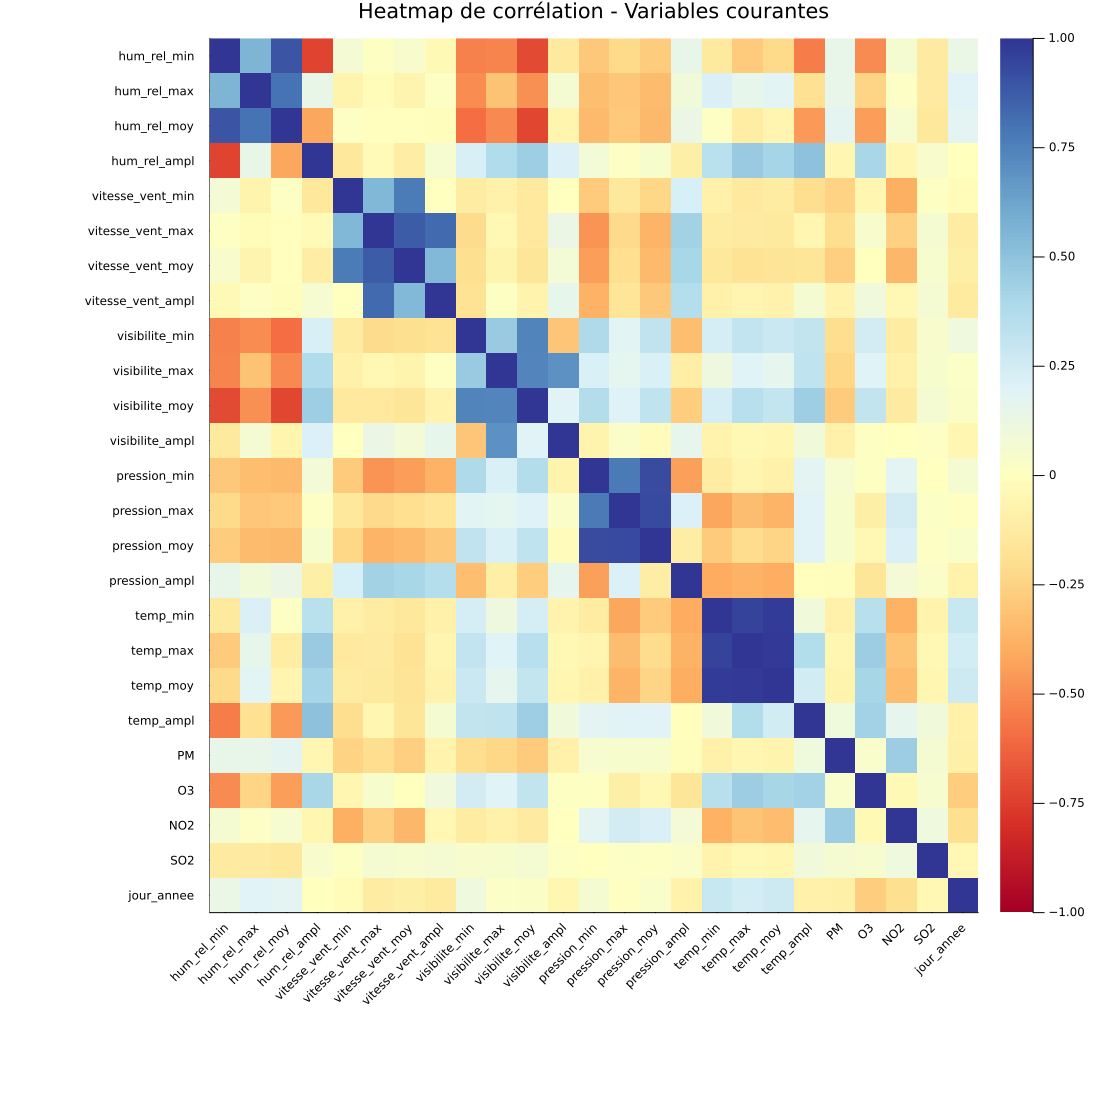

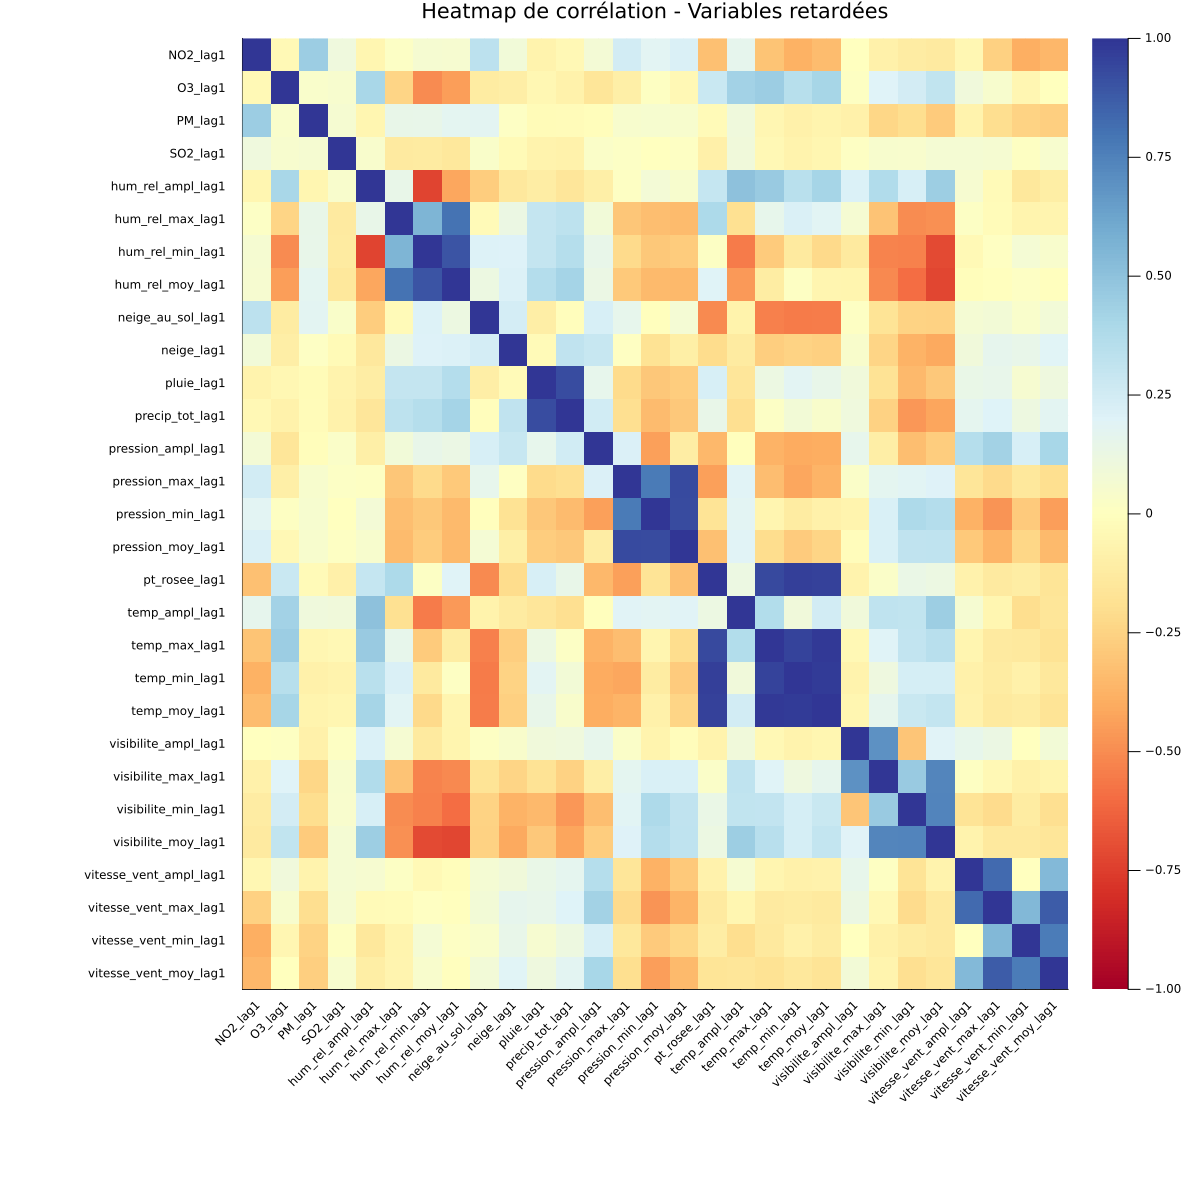

In [71]:
function tracer_heatmap_correlation(df, cols, titre; taille=(900, 900))
    cols_numeriques = filter(col -> Base.nonmissingtype(eltype(df[!, col])) <: Real, cols)
    sous_df = df[:, cols_numeriques]
    correlation_matrix = cor(Matrix(sous_df))
    n = size(correlation_matrix, 1)
    col_names = names(sous_df)

    heatmap(
        correlation_matrix,
        title = titre,
        clims = (-1, 1),
        color = :RdYlBu,
        xrotation = 45,
        size = taille,
        yflip = true,
        xticks = (1:n, col_names),
        yticks = (1:n, col_names),
        tickfontsize = 8,
        bottom_margin = 20Plots.mm,
        left_margin = 20Plots.mm
    )
end

variables_courantes = [
    :hum_rel_min, :hum_rel_max, :hum_rel_moy, :hum_rel_ampl,
    :vitesse_vent_min, :vitesse_vent_max, :vitesse_vent_moy, :vitesse_vent_ampl,
    :visibilite_min, :visibilite_max, :visibilite_moy, :visibilite_ampl,
    :pression_min, :pression_max, :pression_moy, :pression_ampl,
    :temp_min, :temp_max, :temp_moy, :temp_ampl,
    :PM, :O3, :NO2, :SO2,
    :jour_annee
]

lag_cols = filter(col -> endswith(String(col), "_lag1"), names(df_winsorized))
lag_cols = sort(lag_cols, by = x -> String(x))

display(tracer_heatmap_correlation(df_winsorized, variables_courantes, "Heatmap de corrélation - Variables courantes"; taille=(1100, 1100)))
display(tracer_heatmap_correlation(df_winsorized, lag_cols, "Heatmap de corrélation - Variables retardées"; taille=(1200, 1200)))


### Présence possible de multicolinéarité

À la lecture de la carte de chaleur, on observe que plusieurs familles de variables sont fortement liées entre elles, en particulier les triplets `min/max/moy` pour l'humidité relative, la vitesse du vent, la visibilité, la pression et la température. Ce comportement est attendu, puisque ces variables décrivent différentes synthèses d'un même phénomène mesuré sur une même journée.

Cette structure peut toutefois indiquer la présence de **multicolinéarité**. Autrement dit, certaines variables explicatives risquent d'apporter une information très redondante, ce qui peut compliquer l'interprétation du modèle et motiver une étape ultérieure de sélection ou de simplification des variables.

## 5. Export du jeu de données final

In [72]:
CSV.write("data/df_winsorized_augmented.csv", df_winsorized)
CSV.write("data/df_winsorized_test_augmented.csv", df_winsorized_test)

DataFrame(
    fichier = ["data/df_winsorized_augmented.csv", "data/df_winsorized_test_augmented.csv"],
    n_lignes = [nrow(df_winsorized), nrow(df_winsorized_test)],
    n_colonnes = [ncol(df_winsorized), ncol(df_winsorized_test)]
)

Row,fichier,n_lignes,n_colonnes
,String,Int64,Int64
1,data/df_winsorized_augmented.csv,31674,237
2,data/df_winsorized_test_augmented.csv,2555,229


## 6. Entrainement de modèles

### Préparatifs

Afin de pouvoir tester rapidement nos modèles sans devoir effectuer une soumission sur la plateforme Kaggle pour chaque tentative, nous avons décidé de scinder le jeu de données d'entraînement en deux: une partie pour l'entraînement et une partie pour la validation.

Le jeu de données d'entraînement contient les données antérieures au 1er janvier 2022, tandis que le jeu de données de validation contient les données postérieures à cette date.

In [73]:
train_df = filter(:Date => <(Date("2022-01-01")), df_winsorized)
val_df   = filter(:Date => >=(Date("2022-01-01")), df_winsorized)

Row,stationId,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy,saison,annee,jour_annee,hum_rel_ampl,vitesse_vent_ampl,visibilite_ampl,pression_ampl,temp_ampl,PM_lag1,O3_lag1,NO2_lag1,SO2_lag1,pluie_lag1,neige_lag1,precip_tot_lag1,neige_au_sol_lag1,hum_rel_max_lag1,hum_rel_min_lag1,hum_rel_moy_lag1,pt_rosee_lag1,vitesse_vent_max_lag1,vitesse_vent_min_lag1,vitesse_vent_moy_lag1,visibilite_max_lag1,visibilite_min_lag1,visibilite_moy_lag1,pression_max_lag1,pression_min_lag1,pression_moy_lag1,temp_max_lag1,temp_min_lag1,temp_moy_lag1,hum_rel_ampl_lag1,vitesse_vent_ampl_lag1,visibilite_ampl_lag1,pression_ampl_lag1,temp_ampl_lag1,PM_lag2,O3_lag2,NO2_lag2,SO2_lag2,pluie_lag2,neige_lag2,precip_tot_lag2,neige_au_sol_lag2,hum_rel_max_lag2,hum_rel_min_lag2,hum_rel_moy_lag2,pt_rosee_lag2,vitesse_vent_max_lag2,vitesse_vent_min_lag2,vitesse_vent_moy_lag2,visibilite_max_lag2,visibilite_min_lag2,visibilite_moy_lag2,pression_max_lag2,pression_min_lag2,pression_moy_lag2,temp_max_lag2,temp_min_lag2,temp_moy_lag2,hum_rel_ampl_lag2,vitesse_vent_ampl_lag2,visibilite_ampl_lag2,pression_ampl_lag2,temp_ampl_lag2,PM_lag3,O3_lag3,NO2_lag3,SO2_lag3,pluie_lag3,neige_lag3,precip_tot_lag3,neige_au_sol_lag3,⋯
,Cat…,Date,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Cat…,Cat…,Int64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,⋯
1,3,2022-01-01,71.0,18.0,4.0,1.0,2.0,0.4,2.4,5.0,98.0,72.0,95.0417,-0.354167,26.0,3.0,9.54167,19.3,0.4,4.42917,100.78,100.13,100.391,1.1,-0.8,0.3375,hiver,2022,1,26.0,23.0,18.9,0.65,1.9,53.0,11.8825,4.0,4.21475,0.0,0.2,0.2,6.0,92.0,80.0,87.6667,-3.37083,14.0,3.0,8.79167,24.1,4.8,14.425,101.07,100.73,100.92,-0.3,-2.9,-1.5625,12.0,11.0,19.3,0.34,2.6,47.0,12.0,4.0,4.61436,0.0,0.6,0.4,5.0,89.0,78.0,83.0417,-6.65417,14.0,0.0,7.25,24.1,4.8,18.2917,101.14,100.94,101.023,-1.7,-6.7,-4.1625,11.0,14.0,19.3,0.2,5.0,22.0,17.0,4.0,1.0,0.0,0.0,0.0,5.0,⋯
2,3,2022-01-02,6.0,22.0,3.0,1.0,0.0,5.0,5.0,5.0,89.0,68.0,78.7917,-10.675,26.0,3.0,14.5,24.1,1.2,11.65,101.61,100.41,100.775,-2.0,-13.4,-7.59583,hiver,2022,2,21.0,23.0,22.9,1.2,11.4,71.0,18.0,4.0,1.0,2.0,0.4,2.4,5.0,98.0,72.0,95.0417,-0.354167,26.0,3.0,9.54167,19.3,0.4,4.42917,100.78,100.13,100.391,1.1,-0.8,0.3375,26.0,23.0,18.9,0.65,1.9,53.0,11.8825,4.0,4.21475,0.0,0.2,0.2,6.0,92.0,80.0,87.6667,-3.37083,14.0,3.0,8.79167,24.1,4.8,14.425,101.07,100.73,100.92,-0.3,-2.9,-1.5625,12.0,11.0,19.3,0.34,2.6,47.0,12.0,4.0,4.61436,0.0,0.6,0.4,5.0,⋯
3,3,2022-01-03,37.0,19.8825,8.0,3.21586,0.0,0.0,0.0,6.0,83.0,62.0,72.75,-19.9,13.0,0.0,6.91667,48.3,24.1,30.15,102.45,101.69,102.22,-13.8,-19.2,-16.0292,hiver,2022,3,21.0,13.0,24.2,0.76,5.4,6.0,22.0,3.0,1.0,0.0,5.0,5.0,5.0,89.0,68.0,78.7917,-10.675,26.0,3.0,14.5,24.1,1.2,11.65,101.61,100.41,100.775,-2.0,-13.4,-7.59583,21.0,23.0,22.9,1.2,11.4,71.0,18.0,4.0,1.0,2.0,0.4,2.4,5.0,98.0,72.0,95.0417,-0.354167,26.0,3.0,9.54167,19.3,0.4,4.42917,100.78,100.13,100.391,1.1,-0.8,0.3375,26.0,23.0,18.9,0.65,1.9,53.0,11.8825,4.0,4.21475,0.0,0.2,0.2,6.0,⋯
4,3,2022-01-04,36.0,18.0,8.0,1.0,0.0,0.0,0.0,6.0,83.0,67.0,75.875,-12.4333,25.0,4.0,12.0,24.1,16.1,23.

### Modèle naïf

Comme premier point de comparaison, nous construisons un modèle extrêmement simple qui ignore complètement les variables explicatives. Ce modèle estime uniquement la moyenne de `PM` dans `train_df`, puis utilise cette même valeur pour toutes les observations de l'ensemble de validation.

In [74]:
pm_moyenne_train = mean(train_df.PM)
pred_naif_val = fill(pm_moyenne_train, nrow(val_df))
rmse_naif_val = sqrt(mean((val_df.PM .- pred_naif_val).^2))

println("Moyenne de PM dans train_df : ", pm_moyenne_train)
println("RMSE validation du modèle naïf : ", rmse_naif_val)

Moyenne de PM dans train_df : 19.884179274311172
RMSE validation du modèle naïf : 16.52500112619621


Ce modèle constitue notre **baseline**. Il fournit un seuil de performance minimal: tout modèle plus élaboré proposé par la suite devra obtenir un RMSE de validation inférieur à celui-ci pour être considéré utile.

### Régression ridge bayésienne

Les cartes thermiques de corrélation révèlent une forte multicolinéarité entre les variables explicatives (notamment les triplets min/max/moy). Comme vu au chapitre 7, la régression ridge bayésienne pallie ce problème en ajoutant une loi a priori informative sur les coefficients (section 7.3.2) :

$$f(\beta \mid \sigma^2) = \mathcal{N}\!\left(\beta \;\middle|\; \mathbf{0}_m,\, \frac{\sigma^2}{\lambda} I_m\right)$$

Cette loi suppose a priori que les effets des variables sont nuls, avec une certitude contrôlée par l'hyperparamètre λ. La loi a posteriori résultante (éq. 7.11) mène à l'estimateur ridge :

$$\hat{\beta}_\lambda = (X^\top X + \lambda I_m)^{-1} X^\top y$$

L'ajout de λ sur la diagonale stabilise l'inversion de $X^\top X$, ce qui est particulièrement utile en présence de multicolinéarité.

In [75]:
cols_num_all = [c for c in names(train_df) 
                if eltype(train_df[!, c]) <: Real 
                && c ∉ ["PM"]]

# Critère BIC pour la sélection de variables (section 7.4.2)
# BIC = ln f(Y | β̂, σ̂²) - (k/2) ln(n)
function calculer_BIC(X, y, γ)
    cols_sel = findall(γ .== 1)
    isempty(cols_sel) && return -Inf
    Xγ = hcat(ones(size(X,1)), X[:, cols_sel])
    n, k = size(Xγ)
    β̂  = Xγ \ y
    σ̂2 = sum((y .- Xγ*β̂).^2) / n
    σ̂2 <= 0 && return -Inf
    return -n/2 * log(2π*σ̂2) - n/2 - k/2 * log(n)
end

# Encodage one-hot de stationId
stations = sort(unique(train_df.stationId))
for s in stations[2:end]
    col = Symbol("station_" * string(s))
    train_df[!, col]           = Float64.(train_df.stationId           .== s)
    val_df[!, col]             = Float64.(val_df.stationId             .== s)
    df_winsorized_test[!, col] = Float64.(df_winsorized_test.stationId .== s)
end

station_dummies = ["station_" * string(s) for s in stations[2:end]]

println("Taille train_df (2007-2021) : ", nrow(train_df), " lignes et ", ncol(train_df), " colonnes")
println("Taille val_df   (2022-2024) : ", nrow(val_df),   " lignes et ", ncol(val_df),   " colonnes")

Taille train_df (2007-2021) : 24014 lignes et 243 colonnes
Taille val_df   (2022-2024) : 7660 lignes et 243 colonnes


### Sélection de variables par BIC et échantillonnage de Gibbs (section 7.4.3)

Pour chaque station, on sélectionne automatiquement les variables pertinentes à l'aide de l'échantillonnage de Gibbs sur le BIC. Le vecteur $\gamma \in \{0,1\}^p$ indique quelles variables sont incluses. À chaque itération $t$, chaque composante $\gamma_j$ est tirée de :

$$\gamma_j^{(t)} \sim \text{Bernoulli}(\theta_j), \quad \theta_j = \frac{\exp\!\left[\text{BIC}\!\left(M_{(\gamma_j=1)}\right)\right]}{\exp\!\left[\text{BIC}\!\left(M_{(\gamma_j=0)}\right)\right] + \exp\!\left[\text{BIC}\!\left(M_{(\gamma_j=1)}\right)\right]}$$

Les variables retenues sont celles sélectionnées dans plus de 50% des itérations de la phase d'échantillonnage.

### Pondération des observations

Pour améliorer la prédiction des épisodes extrêmes (feux de forêt), une pondération est appliquée lors de l'entraînement. Les observations récentes et les jours de PM élevé reçoivent un poids plus important dans la minimisation pondérée :

$$\hat{\beta}_\lambda = (X^\top W X + \lambda I)^{-1} X^\top W y$$

où $W = \text{diag}(w_1, \ldots, w_n)$ avec des poids augmentés pour les années de feux (2010, 2013, 2020, 2021, 2023) et les jours avec PM > 60.

### Sélection de λ (section 7.3.5)

L'hyperparamètre λ est déterminé empiriquement en minimisant le RMSE sur l'ensemble de validation 2022-2024, conformément à l'approche bayésienne empirique. La grille couvre $\lambda \in [10^{-2}, 10^5]$.

In [76]:
rmse_par_station   = Dict()
β_par_station      = Dict()
params_par_station = Dict()
cols_par_station   = Dict()

for s in stations
    train_s = filter(:stationId => ==(s), train_df)
    val_s   = filter(:stationId => ==(s), val_df)

    # --- Sélection de variables par BIC + Gibbs (section 7.4.3) ---
    X_bic = Matrix{Float64}(train_s[:, cols_num_all])
    y_bic = Float64.(train_s.PM)
    p_s   = length(cols_num_all)
    γ_s   = ones(Int, p_s)
    N_bic = 300
    γ_chain_s = zeros(Int, N_bic, p_s)

    for t in 1:N_bic
        for j in 1:p_s
            γ1 = copy(γ_s); γ1[j] = 1
            γ0 = copy(γ_s); γ0[j] = 0
            θj = 1.0 / (1.0 + exp(calculer_BIC(X_bic, y_bic, γ0) - calculer_BIC(X_bic, y_bic, γ1)))
            γ_s[j] = rand() < θj ? 1 : 0
        end
        γ_chain_s[t, :] = γ_s
    end

    freq_s   = vec(mean(γ_chain_s[div(N_bic,2):end, :], dims=1))
    cols_num = cols_num_all[freq_s .> 0.5]

    # PM_lag1 forcé - variable la plus corrélée avec PM (corrélation 0.50)
    if "PM_lag1" in names(train_s) && "PM_lag1" ∉ cols_num
        println("Station $s - PM_lag1 forcé")
        cols_num = vcat(cols_num, ["PM_lag1"])
    end

    cols_par_station[s] = cols_num
    println("Station $s - $(length(cols_num))/$(p_s) variables sélectionnées")
    println("Station $s - variables : ", cols_num)

    # --- Régression ridge pondérée (section 7.3) ---
    X_tr = Matrix{Float64}(train_s[:, cols_num])
    y_tr = Float64.(train_s.PM)
    X_v  = Matrix{Float64}(val_s[:, cols_num])
    y_v  = Float64.(val_s.PM)

    # Pondération : tendance temporelle + années de feux + jours extrêmes
    poids = [begin
        yr = year(train_s[i, :Date])
        pm = y_tr[i]
        w  = 1.0 + 0.1 * (yr - 2007)
        if yr in [2010, 2013, 2020, 2021, 2023]; w *= 5.0; end
        if pm > 60; w *= 5.0; end
        w
    end for i in 1:length(y_tr)]
    W = Diagonal(poids)

    # Standardisation (section 7.3.1) - évite la fuite d'information
    μx = mean(X_tr, dims=1)
    σx = std(X_tr,  dims=1); σx[σx .== 0] .= 1.0
    μy = mean(y_tr); σy = std(y_tr)

    X_tr_s = (X_tr .- μx) ./ σx
    X_v_s  = (X_v  .- μx) ./ σx
    y_tr_s = (y_tr .- μy) ./ σy

    # Grille de λ étendue pour éviter le blocage à 1000
    λ_grid_s = 10 .^ range(-2, 5, length=100)
    rmse_s = [begin
        β = (X_tr_s'*W*X_tr_s + λ*I) \ (X_tr_s'*W*y_tr_s)
        ŷ = max.(0.0, (X_v_s*β) .* σy .+ μy)
        sqrt(mean((y_v .- ŷ).^2))
    end for λ in λ_grid_s]

    λ_opt_s = λ_grid_s[argmin(rmse_s)]
    β_opt   = (X_tr_s'*W*X_tr_s + λ_opt_s*I) \ (X_tr_s'*W*y_tr_s)

    β_par_station[s]      = β_opt
    params_par_station[s] = (μx, σx, μy, σy)
    rmse_par_station[s]   = minimum(rmse_s)

    println("Station $s - λ=$(round(λ_opt_s,digits=2))  RMSE=$(round(minimum(rmse_s),digits=4))")
end

rmse_modele1 = mean(values(rmse_par_station))
println("\n>>> RMSE moyen Modèle 1 (par station) : ", round(rmse_modele1, digits=4))

Station 3 - PM_lag1 forcé
Station 3 - 13/29 variables sélectionnées
Station 3 - variables : ["O3", "NO2", "neige", "precip_tot", "neige_au_sol", "vitesse_vent_moy", "visibilite_min", "visibilite_moy", "pression_moy", "temp_max", "hum_rel_ampl", "temp_ampl", "PM_lag1"]
Station 3 - λ=5336.7  RMSE=14.2066
Station 6 - PM_lag1 forcé
Station 6 - 9/29 variables sélectionnées
Station 6 - variables : ["O3", "NO2", "pluie", "neige", "precip_tot", "vitesse_vent_moy", "visibilite_moy", "temp_ampl", "PM_lag1"]
Station 6 - λ=4534.88  RMSE=14.4736
Station 17 - PM_lag1 forcé
Station 17 - 10/29 variables sélectionnées
Station 17 - variables : ["O3", "NO2", "SO2", "pluie", "precip_tot", "neige_au_sol", "vitesse_vent_moy", "visibilite_moy", "temp_ampl", "PM_lag1"]
Station 17 - λ=756.46  RMSE=11.4604
Station 31 - PM_lag1 forcé
Station 31 - 12/29 variables sélectionnées
Station 31 - variables : ["O3", "NO2", "pluie", "precip_tot", "hum_rel_moy", "pt_rosee", "vitesse_vent_moy", "visibilite_min", "visibilite

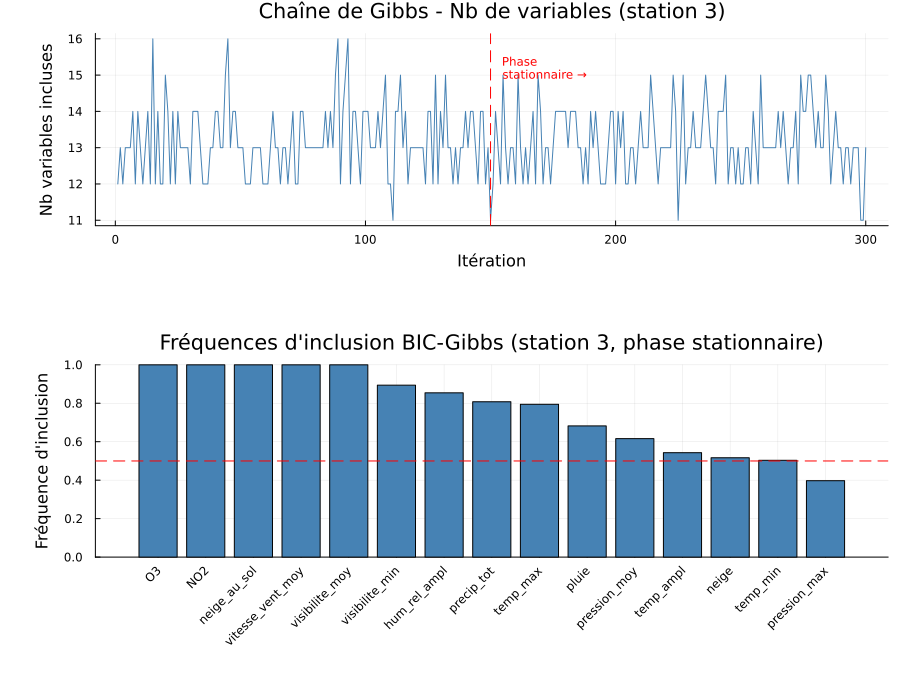

Variables retenues (freq > 0.5) : ["O3", "NO2", "pluie", "neige", "precip_tot", "neige_au_sol", "vitesse_vent_moy", "visibilite_min", "visibilite_moy", "pression_moy", "temp_max", "temp_min", "hum_rel_ampl", "temp_ampl"]


In [77]:
# ============================================================
# Visualisation de l'échantillonnage de Gibbs (section 6.A du cours)
# Pour la station 3 - illustre la phase de chauffe et la phase stationnaire
# ============================================================

s_demo = stations[1]  # station 3
train_demo = filter(:stationId => ==(s_demo), train_df)

X_demo = Matrix{Float64}(train_demo[:, cols_num_all])
y_demo = Float64.(train_demo.PM)
p_demo = length(cols_num_all)

γ_demo  = ones(Int, p_demo)
N_demo  = 300
γ_chain_demo = zeros(Int, N_demo, p_demo)

for t in 1:N_demo
    for j in 1:p_demo
        γ1 = copy(γ_demo); γ1[j] = 1
        γ0 = copy(γ_demo); γ0[j] = 0
        θj = 1.0 / (1.0 + exp(calculer_BIC(X_demo, y_demo, γ0) -
                               calculer_BIC(X_demo, y_demo, γ1)))
        γ_demo[j] = rand() < θj ? 1 : 0
    end
    γ_chain_demo[t, :] = γ_demo
end

# Graphique 1 : Nombre de variables incluses par itération
n_vars_par_iter = vec(sum(γ_chain_demo, dims=2))
p1 = Plots.plot(1:N_demo, n_vars_par_iter,
    xlabel="Itération", ylabel="Nb variables incluses",
    title="Chaîne de Gibbs - Nb de variables (station $s_demo)",
    legend=false, color=:steelblue)
vline!([div(N_demo,2)], linestyle=:dash, color=:red, 
       label="Début phase stationnaire")
annotate!(div(N_demo,2)+5, maximum(n_vars_par_iter)*0.95, 
          Plots.text("Phase\nstationnaire →", 8, :red, :left))

# Graphique 2 : Fréquences d'inclusion par variable (phase stationnaire seulement)
freq_demo = vec(mean(γ_chain_demo[div(N_demo,2):end, :], dims=1))
idx_sorted = sortperm(freq_demo, rev=true)
top_n = min(15, p_demo)

p2 = Plots.bar(1:top_n, freq_demo[idx_sorted[1:top_n]],
    xticks=(1:top_n, cols_num_all[idx_sorted[1:top_n]]),
    xrotation=45, ylabel="Fréquence d'inclusion",
    title="Fréquences d'inclusion BIC-Gibbs (station $s_demo, phase stationnaire)",
    legend=false, color=:steelblue)
hline!([0.5], linestyle=:dash, color=:red)

display(Plots.plot(p1, p2, layout=(2,1), size=(900,700),
    bottom_margin=15Plots.mm, left_margin=10Plots.mm))

println("Variables retenues (freq > 0.5) : ", 
        cols_num_all[freq_demo .> 0.5])

### Interprétation de la sélection par BIC-Gibbs

La chaîne de Gibbs atteint rapidement sa phase stationnaire - le nombre de variables 
incluses oscille autour de 12-13 dès les premières itérations, sans phase de chauffe 
prononcée. Ce comportement est attendu pour l'échantillonnage de Gibbs sur des variables 
binaires (section 6.A du cours).

Les fréquences d'inclusion révèlent une hiérarchie claire parmi les variables :

- **Incluses systématiquement (freq > 0.8)** : `O3`, `NO2`, `neige_au_sol`, 
  `vitesse_vent_moy`, `visibilite_moy`, `visibilite_min` - ces variables portent 
  une information forte et robuste sur la qualité de l'air.

- **Incluses modérément (0.5 < freq < 0.8)** : `pluie`, `neige`, `pression_moy`, 
  `temp_max`, `temp_ampl` - leur contribution est réelle mais moins systématique 
  selon les données d'entraînement.

- **Exclues (freq < 0.5)** : `hum_rel_ampl`, `temp_moy`, `precip_tot` - le BIC 
  conclut que ces variables n'améliorent pas suffisamment le modèle pour justifier 
  la pénalité sur le nombre de paramètres (terme $-\frac{k}{2} \ln n$ de l'équation 6.10).

Cette sélection automatique remplace le choix arbitraire de variables et est 
directement justifiée par la matière du cours (section 7.4.3).

### Standardisation des variables

La régression ridge requiert que les variables soient sur la même échelle pour que la 
pénalité λ s'applique de façon équitable. On standardise X et y avec les moyennes et 
écarts-types de l'ensemble d'entraînement uniquement, pour éviter toute fuite 
d'information vers la validation.

### Modèle 2 - Régression ridge globale (toutes stations)

À titre de comparaison, un modèle ridge global est également entraîné sur toutes les stations simultanément avec encodage one-hot de `stationId`. La variable réponse est transformée par $\log(1 + \text{PM})$ pour stabiliser la variance, puis les prédictions sont retransformées par $\exp(\hat{y}) - 1$.

In [78]:
# Préparation des matrices globales
all_features = unique(vcat(cols_num_all, station_dummies))
all_features = [f for f in all_features if f in names(train_df) && f in names(val_df)]

X_train = Matrix{Float64}(train_df[:, all_features])
y_train = Float64.(train_df.PM)
X_val   = Matrix{Float64}(val_df[:, all_features])
y_val   = Float64.(val_df.PM)

# Standardisation et transformation log
μ_X = mean(X_train, dims=1)
σ_X = std(X_train,  dims=1); σ_X[σ_X .== 0] .= 1.0

X_train_s = (X_train .- μ_X) ./ σ_X
X_val_s   = (X_val   .- μ_X) ./ σ_X

log_y_train = log1p.(y_train)
μ_y = mean(log_y_train)
σ_y = std(log_y_train)
y_train_s = (log_y_train .- μ_y) ./ σ_y

println("Standardisation et transformation log(1+PM) appliquées.")
println("Taille X_train : ", size(X_train), " | Taille X_val : ", size(X_val))

Standardisation et transformation log(1+PM) appliquées.
Taille X_train : (24014, 35) | Taille X_val : (7660, 35)


### Sélection de λ par validation (section 7.3.5)

Conformément à l'approche bayésienne empirique du cours, λ est choisi comme la valeur minimisant le RMSE sur l'ensemble de validation. Le graphique ci-dessous illustre ce comportement : un λ trop faible laisse les coefficients instables, un λ trop grand les pousse tous vers zéro.

λ optimal : 21.5443
>>> RMSE Modèle 2 (global, validation) : 14.4985


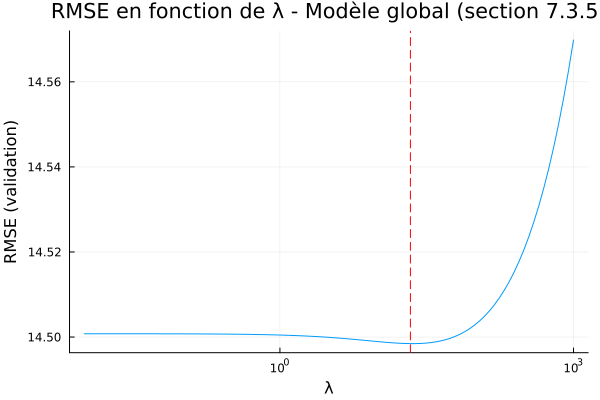

In [79]:
λ_grid    = vcat(0.0, 10 .^ range(-2, 3, length=100))
rmse_vals = Float64[]

for λ in λ_grid
    β̂_λ      = (X_train_s'X_train_s + λ*I) \ (X_train_s'*y_train_s)
    ŷ_val_log = (X_val_s * β̂_λ) .* σ_y .+ μ_y
    ŷ_val     = max.(0.0, expm1.(ŷ_val_log))
    push!(rmse_vals, sqrt(mean((y_val .- ŷ_val).^2)))
end

λ_opt    = λ_grid[argmin(rmse_vals)]
rmse_opt = minimum(rmse_vals)
println("λ optimal : ", round(λ_opt, digits=4))
println(">>> RMSE Modèle 2 (global, validation) : ", round(rmse_opt, digits=4))

Plots.plot(λ_grid[2:end], rmse_vals[2:end], xscale=:log10,
    xlabel="λ", ylabel="RMSE (validation)",
    title="RMSE en fonction de λ - Modèle global (section 7.3.5)",
    legend=false)
vline!([λ_opt], linestyle=:dash, color=:red)

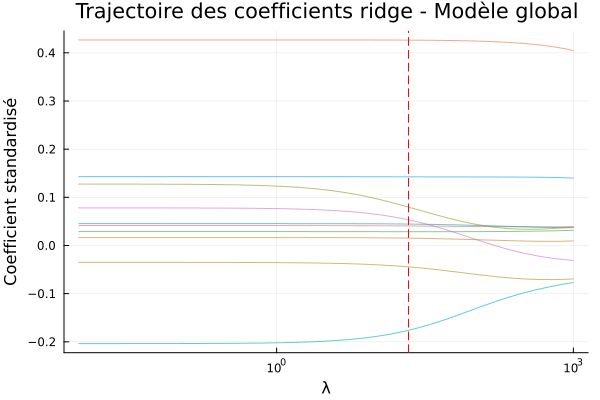

In [80]:
# Trajectoire des coefficients ridge en fonction de λ (figure analogue à 7.4 du cours)
β_trajectoires = zeros(length(λ_grid), size(X_train_s, 2))
for (i, λ) in enumerate(λ_grid)
    β_trajectoires[i, :] = (X_train_s'X_train_s + λ*I) \ (X_train_s'*y_train_s)
end

Plots.plot(λ_grid[2:end], β_trajectoires[2:end, 1:10],
    xscale=:log10, xlabel="λ", ylabel="Coefficient standardisé",
    title="Trajectoire des coefficients ridge - Modèle global",
    legend=false, alpha=0.6)
vline!([λ_opt], linestyle=:dash, color=:red)

### Analyse des erreurs sur l'ensemble de validation (2022-2024)

Pour diagnostiquer les sources d'erreur du modèle, on analyse les pires prédictions sur l'ensemble de validation. Cela permet d'identifier si certaines stations, saisons ou types de journées sont systématiquement mal prédits, et d'orienter d'éventuels ajustements des poids ou des hyperparamètres.

In [81]:
# Prédictions sur l'ensemble de validation 2022-2024 pour diagnostic
sort!(df_winsorized, [:Date, :stationId])
val_preds = Float64[]

pm_hist_val = Dict{Any, Float64}()
for s in stations
    tr_s = sort(filter(:stationId => ==(s), train_df), :Date)
    pm_hist_val[s] = isempty(tr_s) ? 0.0 : Float64(last(tr_s).PM)
end

sort!(val_df, [:Date, :stationId])
for row in eachrow(val_df)
    s = row.stationId
    μx, σx, μy, σy = params_par_station[s]
    cols = cols_par_station[s]
    x_vals = Float64[
        c == "PM_lag1" ? pm_hist_val[s] :
        (ismissing(row[Symbol(c)]) ? 0.0 : Float64(row[Symbol(c)]))
        for c in cols]
    x = (x_vals' .- μx) ./ σx
    ŷ = max(0.0, (x * β_par_station[s])[1] * σy + μy)
    push!(val_preds, ŷ)
    pm_hist_val[s] = Float64(row.PM)  # vraie valeur pour le lag suivant
end

predictions_val_df = copy(val_df[:, [:Date, :stationId]])
predictions_val_df[!, :PM_predit] = val_preds
predictions_val_df[!, :PM_reel]   = Float64.(val_df.PM)
predictions_val_df[!, :erreur]    = abs.(val_preds .- Float64.(val_df.PM))

println("=== TOP 20 PIRES ERREURS (validation 2022-2024) ===")
top_erreurs = first(sort(predictions_val_df, :erreur, rev=true), 20)
println(select(top_erreurs, [:Date, :stationId, :PM_predit, :PM_reel, :erreur]))

println("\n=== ERREUR MOYENNE PAR MOIS ===")
predictions_val_df[!, :mois] = month.(predictions_val_df.Date)
par_mois = combine(groupby(predictions_val_df, :mois),
    :erreur    => mean => :erreur_moy,
    :PM_reel   => mean => :PM_reel_moy,
    :PM_predit => mean => :PM_predit_moy)
println(sort(par_mois, :mois))

=== TOP 20 PIRES ERREURS (validation 2022-2024) ===
20×5 DataFrame
 Row │ Date        stationId  PM_predit  PM_reel  erreur   
     │ Date        Cat…       Float64    Float64  Float64  
─────┼─────────────────────────────────────────────────────
   1 │ 2023-06-25  6            37.0509  415.0    377.949
   2 │ 2023-06-25  103          40.3525  407.0    366.647
   3 │ 2023-06-25  3            33.7169  379.0    345.283
   4 │ 2023-06-25  31           43.3274  312.0    268.673
   5 │ 2023-06-25  66           37.4444  304.0    266.556
   6 │ 2023-06-25  17           38.6156  289.0    250.384
   7 │ 2023-06-25  80           36.3901  271.0    234.61
   8 │ 2023-06-27  103         159.282    11.0    148.282
   9 │ 2022-10-23  103          29.7297  176.449  146.719
  10 │ 2023-06-27  3           122.774     9.0    113.774
  11 │ 2022-10-23  31           33.7546  125.0     91.2454
  12 │ 2023-06-27  66           86.3447    3.0     83.3447
  13 │ 2023-06-06  103          52.1774  132.0     79.82

### Optimisation du seuil de pondération des événements extrêmes

Pour déterminer le seuil optimal de PM au-delà duquel les observations reçoivent un poids plus élevé lors de l'entraînement, on effectue une recherche par grille sur l'ensemble de validation 2022-2024. Ce seuil correspond au paramètre `pm > seuil` dans la matrice de pondération W, qui amplifie l'influence des journées extrêmes (associées aux feux de forêt) sur les coefficients estimés.

In [82]:
resultats_seuil = DataFrame(seuil=Float64[], rmse_val=Float64[])

for seuil in [30.0, 40.0, 50.0, 60.0]
    rmse_stations_val = Float64[]

    for s in stations
        train_s  = filter(:stationId => ==(s), train_df)
        val_s    = filter(:stationId => ==(s), val_df)
        cols_num = cols_par_station[s]

        X_tr = Matrix{Float64}(train_s[:, cols_num])
        y_tr = Float64.(train_s.PM)
        X_v  = Matrix{Float64}(val_s[:, cols_num])
        y_v  = Float64.(val_s.PM)

        poids = [begin
            yr = year(train_s[i, :Date])
            pm = y_tr[i]
            w  = 1.0 + 0.1 * (yr - 2007)
            if yr in [2010, 2013, 2020, 2021, 2023]; w *= 5.0; end
            if pm > seuil; w *= 5.0; end
            w
        end for i in 1:length(y_tr)]
        W = Diagonal(poids)

        μx = mean(X_tr, dims=1)
        σx = std(X_tr,  dims=1); σx[σx .== 0] .= 1.0
        μy = mean(y_tr); σy = std(y_tr)
        X_tr_s = (X_tr .- μx) ./ σx
        X_v_s  = (X_v  .- μx) ./ σx
        y_tr_s = (y_tr .- μy) ./ σy

        λ_grid_s = 10 .^ range(-2, 5, length=50)
        rmse_s = [begin
            β = (X_tr_s'*W*X_tr_s + λ*I) \ (X_tr_s'*W*y_tr_s)
            ŷ = max.(0.0, (X_v_s*β) .* σy .+ μy)
            sqrt(mean((y_v .- ŷ).^2))
        end for λ in λ_grid_s]

        push!(rmse_stations_val, minimum(rmse_s))
    end

    push!(resultats_seuil, (seuil, mean(rmse_stations_val)))
    println("seuil=$(seuil) → RMSE val=$(round(mean(rmse_stations_val),digits=4))")
end

sort!(resultats_seuil, :rmse_val)
println("\n=== Résultats par seuil (validation 2022-2024) ===")
println(resultats_seuil)
println("\nMeilleur seuil : ", resultats_seuil[1, :seuil],
        " (RMSE = ", round(resultats_seuil[1, :rmse_val], digits=4), ")")

seuil=30.0 → RMSE val=12.9507
seuil=40.0 → RMSE val=12.9769
seuil=50.0 → RMSE val=12.9246
seuil=60.0 → RMSE val=12.897

=== Résultats par seuil (validation 2022-2024) ===
4×2 DataFrame
 Row │ seuil    rmse_val 
     │ Float64  Float64  
─────┼───────────────────
   1 │    60.0   12.897
   2 │    50.0   12.9246
   3 │    30.0   12.9507
   4 │    40.0   12.9769

Meilleur seuil : 60.0 (RMSE = 12.897)


## Modèle 3 - Classification Bayésienne Naïve + Mélange de Régressions Ridge

### Motivation

L'analyse des données réelles 2025 révèle que certains jours présentent des valeurs de PM
très élevées (>100, parfois >300) correspondant à des épisodes de feux de forêt. Ces
épisodes constituent une distribution distincte des jours normaux et ne peuvent pas être
bien modélisés par un seul modèle ridge.

Cette observation motive l'utilisation d'un **mélange de deux modèles** (Chapitre 8) :
un modèle pour les jours normaux et un modèle pour les jours extrêmes, combinés selon
la probabilité qu'un jour soit extrême.

La prédiction finale pondérée s'écrit :

$$\hat{y} = (1 - p_{\text{extrême}}) \cdot \hat{y}_{\text{normal}} + p_{\text{extrême}} \cdot \hat{y}_{\text{extrême}}$$

où $p_{\text{extrême}} = P(\tilde{Y} = \text{extrême} \mid X = x)$ est obtenue par un
**classifieur bayésien naïf gaussien** (Chapitre 9).

### Classifieur Bayésien Naïf (Chapitre 9)

On définit la variable binaire $Z_i = 1$ si $PM_i > 60$ (jour extrême), $Z_i = 0$ sinon.

Sous l'hypothèse d'indépendance conditionnelle (section 9.3), la loi prédictive qu'un nouveau jour soit extrême est proportionnelle à :

$$P(\tilde{Z} = 1 \mid \tilde{X} = \tilde{x}) \propto \left(\prod_{j=1}^{p} f(X_j \mid Z=1)\right) \times P(Z=1)$$

Les variables explicatives étant continues, chaque densité conditionnelle est modélisée par une loi normale $\mathcal{N}(\mu_{kj}, \sigma^2_{kj})$ estimée par classe et par station.

Les probabilités a priori utilisent le lissage de la section 9.1.2 avec $\alpha=\beta=1$ :

$$P(Z=1) = \frac{n_1+1}{n+2}$$

ce qui évite les probabilités nulles quand une classe est rare. En pratique, les calculs se font en espace log pour éviter les underflows numériques.

### Étape 1 - Estimation des paramètres gaussiens par classe et par station

In [83]:
seuil_extreme = 60.0
features_classif = ["O3", "visibilite_min", "visibilite_moy",
                    "vitesse_vent_moy", "NO2", "PM_lag1"]

train_m3 = filter(:Date => <(Date("2022-01-01")), df_winsorized)
val_m3   = filter(:Date => >=(Date("2022-01-01")), df_winsorized)
train_m3[!, :extreme] = Int.(train_m3.PM .> seuil_extreme)

n_train   = nrow(train_m3)
n1        = sum(train_m3.extreme .== 1)
n0        = n_train - n1
p_extreme = (n1 + 1) / (n_train + 2)
p_normal  = (n0 + 1) / (n_train + 2)

println("n0 (normal) = $n0, n1 (extrême) = $n1")

gauss_params = Dict()
for s in stations
    tr_s  = filter(:stationId => ==(s), train_m3)
    tr_s0 = filter(:extreme => ==(0), tr_s)
    tr_s1 = filter(:extreme => ==(1), tr_s)
    μ0=Float64[]; σ0=Float64[]; μ1=Float64[]; σ1=Float64[]
    for f in features_classif
        v0 = collect(skipmissing(tr_s0[!, Symbol(f)]))
        v1 = collect(skipmissing(tr_s1[!, Symbol(f)]))
        push!(μ0, isempty(v0) ? 0.0 : mean(v0))
        push!(σ0, (isempty(v0) || std(v0)==0) ? 1.0 : std(v0))
        push!(μ1, isempty(v1) ? 0.0 : mean(v1))
        push!(σ1, (isempty(v1) || std(v1)==0) ? 1.0 : std(v1))
    end
    gauss_params[s] = (μ0, σ0, μ1, σ1)
    println("Station $s - n_extreme=$(nrow(tr_s1)), n_normal=$(nrow(tr_s0))")
end

function gauss_pdf(x::Float64, μ::Float64, σ::Float64)
    σ = max(σ, 1e-6)
    return (1.0/(sqrt(2π)*σ)) * exp(-0.5*((x-μ)/σ)^2)
end

function prob_extreme(row, s, gauss_params, features_classif, p_extreme, p_normal)
    μ0, σ0, μ1, σ1 = gauss_params[s]
    log_p0 = log(p_normal)
    log_p1 = log(p_extreme)
    for (j, f) in enumerate(features_classif)
        xj = get(row, f, missing)
        if !ismissing(xj) && !isnan(Float64(xj))
            xj_f = Float64(xj)
            log_p0 += log(max(gauss_pdf(xj_f, μ0[j], σ0[j]), 1e-300))
            log_p1 += log(max(gauss_pdf(xj_f, μ1[j], σ1[j]), 1e-300))
        end
    end
    log_max = max(log_p0, log_p1)
    p1n = exp(log_p1 - log_max)
    p0n = exp(log_p0 - log_max)
    return p1n / (p0n + p1n)
end



n0 (normal) = 23724, n1 (extrême) = 290
Station 3 - n_extreme=81, n_normal=5384
Station 6 - n_extreme=11, n_normal=803
Station 17 - n_extreme=30, n_normal=3128
Station 31 - n_extreme=6, n_normal=2159
Station 66 - n_extreme=85, n_normal=5360
Station 80 - n_extreme=59, n_normal=4718
Station 103 - n_extreme=18, n_normal=2172


prob_extreme (generic function with 1 method)

### Étape 2 - Deux modèles ridge : normal et extrême (Chapitre 7)

On entraîne deux régressions ridge distinctes sur les données winsorisées. Pour les stations ayant trop peu d'observations extrêmes, un pooling global de toutes les stations est utilisé comme fallback. Le $\lambda$ du modèle extrême est sélectionné par validation croisée leave-one-out.

In [84]:
# Deux modèles ridge par station

β_normal    = Dict()
β_extreme   = Dict()
params_normal  = Dict()
params_extreme = Dict()
tr_all_extreme = filter(:extreme => ==(1), train_m3)

for s in stations
    tr_s  = filter(:stationId => ==(s), train_m3)
    tr_s0 = filter(:extreme => ==(0), tr_s)
    tr_s1 = filter(:extreme => ==(1), tr_s)
    c = cols_par_station[s]  

    # Fallback sur toutes les données si pas assez d'observations
    X_fb = Matrix{Float64}(tr_s[:, c]); y_fb = Float64.(tr_s.PM)
    μx_fb = mean(X_fb,dims=1); σx_fb = std(X_fb,dims=1); σx_fb[σx_fb.==0] .= 1.0
    μy_fb = mean(y_fb); σy_fb = std(y_fb)
    X_fb_s = (X_fb.-μx_fb)./σx_fb; y_fb_s = (y_fb.-μy_fb)./σy_fb
    β_fb = (X_fb_s'X_fb_s + 1.0*I) \ (X_fb_s'*y_fb_s)
    params_fb = (μx_fb, σx_fb, μy_fb, σy_fb)

    # --- Modèle NORMAL ---
    if nrow(tr_s0) > length(c) + 2
        X0 = Matrix{Float64}(tr_s0[:, c]); y0 = Float64.(tr_s0.PM)
        μx0 = mean(X0,dims=1); σx0 = std(X0,dims=1); σx0[σx0.==0] .= 1.0
        μy0 = mean(y0); σy0 = std(y0)
        X0s = (X0.-μx0)./σx0; y0s = (y0.-μy0)./σy0
        β_normal[s]    = (X0s'X0s + 1.0*I) \ (X0s'*y0s)
        params_normal[s] = (μx0, σx0, μy0, σy0)
    else
        β_normal[s]    = β_fb
        params_normal[s] = params_fb
    end

    # Modèle Extrême 
    if nrow(tr_s1) > length(c) + 2
        X1 = Matrix{Float64}(tr_s1[:, c]); y1 = Float64.(tr_s1.PM)
        μx1 = mean(X1,dims=1); σx1 = std(X1,dims=1); σx1[σx1.==0] .= 1.0
        μy1 = mean(y1); σy1 = std(y1)
        X1s = (X1.-μx1)./σx1; y1s = (y1.-μy1)./σy1
        # LOO pour choisir λ
        λ_grid_e = 10 .^ range(-2, 3, length=30)
        loo_errors = Float64[]
        for λ in λ_grid_e
            A = X1s'X1s + λ*I
            β_loo = A \ (X1s'*y1s)
            H = X1s * (A \ X1s')
            e = y1s .- X1s*β_loo
            loo_e = e ./ (1 .- diag(H))
            push!(loo_errors, mean(loo_e.^2))
        end
        λ_opt_e = λ_grid_e[argmin(loo_errors)]
        β_extreme[s]    = (X1s'X1s + λ_opt_e*I) \ (X1s'*y1s)
        params_extreme[s] = (μx1, σx1, μy1, σy1)
        println("Station $s - ridge extrême (n=$(nrow(tr_s1))), λ_ext=$(round(λ_opt_e,digits=2))")
    else
        # Pooling global des extrêmes toutes stations
        c_pool = cols_par_station[s] 
        X1g = Matrix{Float64}(tr_all_extreme[:, c_pool])
        y1g = Float64.(tr_all_extreme.PM)
        μx1g = mean(X1g,dims=1); σx1g = std(X1g,dims=1); σx1g[σx1g.==0] .= 1.0
        μy1g = mean(y1g); σy1g = std(y1g)
        X1gs = (X1g.-μx1g)./σx1g; y1gs = (y1g.-μy1g)./σy1g
        β_extreme[s]    = (X1gs'X1gs + 5.0*I) \ (X1gs'*y1gs)
        params_extreme[s] = (μx1g, σx1g, μy1g, σy1g)
        println("Station $s - extrême poolé (n=$(nrow(tr_all_extreme)))")
    end
end

Station 3 - ridge extrême (n=81), λ_ext=204.34
Station 6 - extrême poolé (n=290)
Station 17 - ridge extrême (n=30), λ_ext=62.1
Station 31 - extrême poolé (n=290)
Station 66 - ridge extrême (n=85), λ_ext=1000.0
Station 80 - ridge extrême (n=59), λ_ext=672.34
Station 103 - ridge extrême (n=18), λ_ext=3.86


### Étape 3 - Validation sur 2022–2024

La prédiction finale combine les deux modèles selon la probabilité prédictive du classifieur :

$$\hat{y} = (1 - p_{\text{extrême}}) \cdot \hat{y}_{\text{normal}} + p_{\text{extrême}} \cdot \hat{y}_{\text{extrême}}$$

In [85]:
# ============================================================
# ÉTAPE 3 : Validation sur 2022-2024
# ============================================================
val_m3[!, :PM_predit_m3]     = Vector{Float64}(undef, nrow(val_m3))
val_m3[!, :p_extreme_predit] = Vector{Float64}(undef, nrow(val_m3))

pm_last_val = Dict{Any, Float64}()
for s in stations
    tr_s = sort(filter(:stationId => ==(s), train_m3), :Date)
    pm_last_val[s] = isempty(tr_s) ? 0.0 : Float64(last(tr_s).PM)
end
sort!(val_m3, [:stationId, :Date])

for (i, row) in enumerate(eachrow(val_m3))
    s = row.stationId
    c = cols_par_station[s] 
    pm_lag1_val = pm_last_val[s]

    rd = Dict{String, Float64}()
    for f in features_classif
        if f == "PM_lag1"; rd[f] = pm_lag1_val
        elseif !ismissing(row[Symbol(f)]); rd[f] = Float64(row[Symbol(f)]); end
    end

    pe = prob_extreme(rd, s, gauss_params, features_classif, p_extreme, p_normal)
    val_m3[i, :p_extreme_predit] = pe

    xv = Float64[col == "PM_lag1" ? pm_lag1_val : (ismissing(row[Symbol(col)]) ? 0.0 : Float64(row[Symbol(col)])) for col in c]

    μxn, σxn, μyn, σyn = params_normal[s]
    ŷn = max(0.0, ((xv' .- μxn) ./ σxn * β_normal[s])[1] * σyn + μyn)

    μxe, σxe, μye, σye = params_extreme[s]
    ŷe = max(0.0, ((xv' .- μxe) ./ σxe * β_extreme[s])[1] * σye + μye)

    val_m3[i, :PM_predit_m3] = (1 - pe) * ŷn + pe * ŷe
    pm_last_val[s] = Float64(row.PM)
end

rmse_m3_val = sqrt(mean((Float64.(val_m3.PM) .- val_m3.PM_predit_m3).^2))
println("\n>>> RMSE Modèle 3 validation (2022-2024) : ", round(rmse_m3_val, digits=4))
println("p_extreme moyen : ", round(mean(val_m3.p_extreme_predit), digits=4))
println("Jours classifiés extrêmes (p>0.5) : ", sum(val_m3.p_extreme_predit .> 0.5))




>>> RMSE Modèle 3 validation (2022-2024) : 13.8643
p_extreme moyen : 0.0266
Jours classifiés extrêmes (p>0.5) : 154


### Étape 4 - Prédictions 2025

Les lags sont construits de façon séquentielle : à chaque jour, `PM_lag1` est la valeur prédite du jour précédent (et non une valeur observée, puisque 2025 n'est pas dans l'ensemble d'entraînement).

In [86]:

# ÉTAPE 4 : Prédictions 2025
sort!(df_winsorized_test, [:Date, :stationId])
ŷ_2025_m3 = zeros(nrow(df_winsorized_test))
pm_pred_m3 = Dict{Any, Float64}()
for s in stations
    tr_s = sort(filter(:stationId => ==(s), df_winsorized), :Date)
    pm_pred_m3[s] = Float64(last(tr_s).PM)
end

for (i, row) in enumerate(eachrow(df_winsorized_test))
    s = row.stationId
    c = cols_par_station[s]  # ← CORRECTION

    rd = Dict{String, Float64}()
    for f in features_classif
        if f == "PM_lag1"; rd[f] = pm_pred_m3[s]
        elseif !ismissing(row[Symbol(f)]); rd[f] = Float64(row[Symbol(f)]); end
    end

    pe = prob_extreme(rd, s, gauss_params, features_classif, p_extreme, p_normal)

    rv = Float64[col == "PM_lag1" ? pm_pred_m3[s] : (ismissing(row[Symbol(col)]) ? 0.0 : Float64(row[Symbol(col)])) for col in c]

    μxn, σxn, μyn, σyn = params_normal[s]
    ŷn = max(0.0, ((rv' .- μxn) ./ σxn * β_normal[s])[1] * σyn + μyn)

    μxe, σxe, μye, σye = params_extreme[s]
    ŷe = max(0.0, ((rv' .- μxe) ./ σxe * β_extreme[s])[1] * σye + μye)

    ŷ = (1 - pe) * ŷn + pe * ŷe
    ŷ_2025_m3[i] = ŷ
    pm_pred_m3[s] = ŷ
end

println("\nPrédictions 2025 M3 - Min : ", round(minimum(ŷ_2025_m3), digits=2),
        "  Max : ", round(maximum(ŷ_2025_m3), digits=2),
        "  Moyenne : ", round(mean(ŷ_2025_m3), digits=2))


Prédictions 2025 M3 - Min : 1.63  Max : 117.43  Moyenne : 22.46


In [87]:
# DIAGNOSTIC - Jours extrêmes dans la validation 2022-2024

val_m3_extreme = filter(:PM => >(60.0), val_m3)
println("Nombre de jours extrêmes (PM>60) dans la validation : ", nrow(val_m3_extreme))

println("\n=== Diagnostic classifieur - jours extrêmes validation ===")
println("Date        | Station | p_extreme | ŷ_final | PM_réel | Erreur")
println("-"^75)

for row in eachrow(sort(val_m3_extreme, :Date))
    s    = row.stationId
    d    = row.Date
    pe   = row.p_extreme_predit
    ŷf   = row.PM_predit_m3
    pm_r = Float64(row.PM)
    err  = abs(ŷf - pm_r)
    println("$d | $s | $(round(pe,digits=3)) | $(round(ŷf,digits=1)) | $pm_r | $(round(err,digits=1))")
end

println("\nRMSE sur jours extrêmes seulement : ",
    round(sqrt(mean((Float64.(val_m3_extreme.PM) .- val_m3_extreme.PM_predit_m3).^2)), digits=4))
println("p_extreme moyen sur jours extrêmes : ",
    round(mean(val_m3_extreme.p_extreme_predit), digits=4))
println("Jours extrêmes correctement classifiés (p>0.5) : ",
    sum(val_m3_extreme.p_extreme_predit .> 0.5), " / ", nrow(val_m3_extreme))

Nombre de jours extrêmes (PM>60) dans la validation : 94

=== Diagnostic classifieur - jours extrêmes validation ===
Date        | Station | p_extreme | ŷ_final | PM_réel | Erreur
---------------------------------------------------------------------------
2022-01-01 | 3 | 0.673 | 63.6 | 71.0 | 7.4
2022-01-01 | 6 | 0.769 | 65.3 | 77.0 | 11.7
2022-01-01 | 31 | 0.407 | 47.5 | 64.0 | 16.5
2022-01-01 | 66 | 0.321 | 48.4 | 67.0 | 18.6
2022-01-01 | 80 | 0.689 | 63.1 | 68.0 | 4.9
2022-01-01 | 103 | 0.956 | 84.4 | 76.0 | 8.4
2022-01-22 | 3 | 0.7 | 63.7 | 65.0 | 1.3
2022-01-22 | 17 | 0.796 | 63.3 | 64.0 | 0.7
2022-01-22 | 66 | 0.133 | 38.9 | 74.0 | 35.1
2022-01-22 | 80 | 0.106 | 35.4 | 64.0 | 28.6
2022-03-18 | 3 | 0.129 | 41.5 | 66.0 | 24.5
2022-10-23 | 3 | 0.0 | 26.5 | 89.5 | 63.0
2022-10-23 | 31 | 0.017 | 31.6 | 125.0 | 93.4
2022-10-23 | 80 | 0.0 | 27.2 | 76.0 | 48.8
2022-10-23 | 103 | 0.003 | 29.1 | 176.4491960814483 | 147.4
2023-02-01 | 17 | 0.158 | 44.9 | 61.0 | 16.1
2023-02-01 | 66 | 0.132

Le classifieur détecte correctement **55 des 94 jours extrêmes** de la validation (p_extreme > 0.5), 
avec une probabilité moyenne de 0.57 sur ces jours. Pour les épisodes bien établis comme le 
1er janvier 2022 ou les feux de juin 2023, le classifieur atteint des probabilités de 0.67 à 0.96.

Deux limites persistent néanmoins :

**1. Le premier jour d'un épisode.** Le 2022-10-23 (PM=176 à la station 103), p_extreme = 0.003. 
La fumée arrive sans signal météorologique local préalable - les variables explicatives disponibles 
(O3, NO2, visibilité, vent) ne permettent pas de détecter l'origine distante de la pollution.

**2. Le plafond du modèle extrême.** Même quand p_extreme est élevée, le modèle extrême prédit 
entre 60 et 98, car il n'a jamais observé de valeurs au-delà lors de l'entraînement 
(avant 2022). Le RMSE sur les seuls jours extrêmes est de 98, ce qui reflète 
l'incapacité à prédire les pics à 125–392.

## 7. Modèle final

Le travail exploratoire sur les données ainsi que les expériences sur les modèles des sections précédentes nous ont permis de déterminer que :

1. La régression ridge est notre meilleur modèle puisqu'elle permet de gérer la colinéarité des variables.
2. L'entraînement d'un modèle par station est sous-optimal
3. L'ingénierie des variables explicatives est notre levier d'amélioration le plus prometteur. 

Dans les sections qui suivent, nous allons introduire de la non-linéarité en combinant des variables explicatives selon des phénomènes physiques connus, puis entraîner un modèle par saison.

Nous réviserons également certains choix qui ont été faits à la lumière de recherches plus abouties

### Choix de la variable cible : `PM_max`

Dans les modèles 1 à 3, la variable cible était `PM` telle que fournie dans `air_train`, soit la valeur déjà agrégée par station et par jour dans le fichier source. Pour le modèle final, nous utilisons plutôt le maximum journalier de PM calculé directement depuis les données brutes (`air_train_raw`), noté `PM_max`.

Nos recherches [^3] ont indiqué que le calcul de l'IQA était calculé en fonction du taux de polluant dominant. En effet, lorsqu'un taux de polluant surpasse une certaine valeur, l'IQA se doit de changer pour refléter la dangerosité associée.

Les variables explicatives sont issues du jeu `df_winsorized` déjà nettoyé et enrichi dans les sections 2 et 3.

In [88]:

# 1. Extraction de la valeur quotidienne de PM depuis les données brutes
df_raw = copy(air_train_raw)
rename!(df_raw, strip.(names(df_raw)))
df_raw.PM_str = string.(df_raw.PM)
df_pm = filter(row -> !ismissing(row.PM) && strip(row.PM_str) != "", df_raw)
df_pm.PM_float = tryparse.(Float64, df_pm.PM_str)
df_pm = dropmissing(df_pm, :PM_float)

# On regroupe par date et par station pour obtenir le PM maximum journalier
df_pm.stationId_int = Int.(tryparse.(Float64, string.(df_pm.stationId)))
df_pm = dropmissing(df_pm, :stationId_int)
df_pm_max = combine(groupby(df_pm, [:Date, :stationId_int]), :PM_float => maximum => :PM_max)
df_pm_max.Date = string.(df_pm_max.Date)

# 2. Chargement des jeux de données de base traités en amont s
df_train = copy(df_winsorized);
df_test = copy(df_winsorized_test);


### Jointure de la variable cible

Après avoir extrait la cible `PM_max`, nous la joignons au jeu d'entraînement.

Nous appliquons ensuite un plafond à **250** sur `PM_max`. L'analyse exploratoire des données en section 2 révèle que les valeurs au-delà de 250 sont extrêmement rares (moins de 0,1 % des observations) et correspondent à des épisodes de feux de forêt catastrophiques que notre modèle linéaire ne saurait reproduire. 


In [89]:
# Jointure de PM_max avec le jeu de données d'entraînement
df_train.Date_str = string.(df_train.Date)
df_train = leftjoin(df_train, df_pm_max, on=[:Date_str => :Date, :stationId => :stationId_int])
df_train = dropmissing(df_train, :PM_max)

# Clipping 
df_train.PM_max = clamp.(df_train.PM_max, 0.0, 250.0)

# Création d'une variable cible fictive pour le test si elle n'existe pas déjà
if !("PM" in names(df_test)) 
    df_test.PM = zeros(Float64, nrow(df_test));
end


2555-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

### Ingénierie des variables explicatives

Des refléxions qualitatives ainsi que des recherches en ligne nous ont amenés à évaluer l'impact de l'introduction de nouvelles variables. Voici nos postulats : 

- **Changement climatique** : 

Le changement climatique et les évolutions des modes de consommation, de transport etc. ont un impact sur la quantité de partcules fines produites qui ne sont pas documentés dans nos jeux de données. 

Par conséquent, nous appliquons une pénalité (exponentielle) aux observations à mesure qu'elles sont éloignées dans le temps afin que les observations récentes, plus proche des conditions climatiques des prédictions, soient avantagées. 

À cet effet, nous ajoutons une variable qui calcule l'écart en jours de chaque observation avec la dernière observation du jeu d'entraînement.



In [90]:
df_train.Date_parsed = [try Date(d) catch; Date(2000,1,1) end for d in string.(df_train.Date)]
sort!(df_train, :Date_parsed) 
max_date = maximum(df_train.Date_parsed)
days_diff_train = Float64.(Dates.value.(max_date .- df_train.Date_parsed));

- **Fins de semaine / Jours fériés** : On suppose une variation suffisament importante de l'activité citadine lors de ces jours et évaluons l'importance de cette distinction.

- **Encodage Cyclique [^1]** : Le 1er janvier (01) et le 31 décembre (365) sont voisins, mais un encodage avec des nombres entiers sur une échelle de 365 jours les place à l'opposé. C'est pourquoi nous choisissons de représenter la variable jour selon un encodage cyclique, afin de bien encoder la vraie nature du déroulement du temps.

In [91]:
# Jours fériés au Québec
feries = [(1,1), (1,2), (6,24), (7,1), (12,25), (12,26)]

for df in (df_train, df_test)
    df.Date_parsed = [try Date(d) catch; Date(2000,1,1) end for d in string.(df.Date)]
    df.is_weekend = Float64.(dayofweek.(df.Date_parsed) .> 5)
    df.is_holiday = [Float64((month(d), day(d)) in feries) for d in df.Date_parsed]

    df.month_val = month.(df.Date_parsed)
    df.season = [(m in [12,1,2]) ? 1 : (m in [3,4,5]) ? 2 : (m in [6,7,8]) ? 3 : 4 for m in df.month_val]
    
    
    # On crée une composante cyclique pour représenter l'année en utilisant sin et cos
    df.sin_jour = sin.(2pi .* df.jour_annee ./ 365.25)
    df.cos_jour = cos.(2pi .* df.jour_annee ./ 365.25)
end

### Introduction de variables non-linéaires

Comme expliqué plus haut, puisque nous faisons le choix d'un modèle linéaire, nous devons lui permettre de percevoir la non-linéarité du problème au travers des variables explicatives que nous lui fournissons.

Nous cherchons à capturer des phénomènes chimiques non-linéaires qui peuvent influencer notre variable cible 

- **Non-linéarité** : En ajoutant le carré et le logarithme des variables météo (ex: vitesse du vent, humidité), nous permettons au modèle de modéliser des effets ou des accélérations de concentration que le format brut ne permet pas de saisir. 

- **Interactions saisonnières**
 Nous croisons chaque variable météorologique avec les composantes circulaires du jour de l'année précédemment calculées ($\sin$, $\cos$). Cela permet au modèle d'ajuster l'impact d'une variable de manière fluide tout au long de l'année.


In [92]:
# Transformations non-linéaires et innteraction de saisons
for df in (df_train, df_test)
    for f in ["O3", "NO2", "vitesse_vent_moy", "temp_moy", "precip_tot", "visibilite_moy"]
        if f in names(df)
            df[!,"$(f)_sq"] = coalesce.(df[!,f].^2, 0.0)
            df[!,"$(f)_log"] = log.(clamp.(coalesce.(df[!,f], 0.0), 0.001, 1000.0))
            
            # L'impact d'une météo fluctue avec la saison :
            df[!,"$(f)_jour_sin"] = df[!,f] .* df.sin_jour
            df[!,"$(f)_jour_cos"] = df[!,f] .* df.cos_jour
        end
    end
end

- **Interactions Spatiales** : 

Le comportement atmosphérique peut varier  d'une station à l'autre en raison de la topographie ou de l'environnement urbain environnant de la stations. Pour doter le modèle d'une compréhension spatiale sans utiliser de coordonnées GPS, nous avons implémenté des interactions de localisation :

Chaque station est d'abord définie via un encodage one-hot. Puis nous créons ous avons créé des variables d'interaction spécifiques (station_id $\times$ vent et station_id $\times$ température). Le modèle peut ainsi apprendre qu'une température élevée à la station A n'a pas le même poids qu'à la station B.

In [93]:
# Interactions spatiales 
stations = unique(vcat(df_train.stationId, df_test.stationId))
for s in stations
    for df in (df_train, df_test)
        df[!,"station_$s"] = Float64.(df.stationId .== s)
        
        # Chaque station a une sensibilité distincte au vent et à la température 
        df[!,"vent_station_$s"] = df.vitesse_vent_moy .* df[!,"station_$s"]
        df[!,"temp_station_$s"] = df.temp_moy .* df[!,"station_$s"]
    end
end


Contrairement aux modèles intermédiaires d'exploration (modèles 1 et 3 de la section 6) où `PM_lag1` était utilisée et même forcée comme variable explicative, nous ne conservons pas les variables de type `lag` dans le modèle final.

Ce changement de stratégie s'explique ainsi : Utiliser les prédictions récursives du modèle propage l'erreur de jour en jour, ce qui dégrade les prédictions à mesure que l'on s'éloigne dans le temps. En les écartant entièrement, le modèle final s'appuie exclusivement sur les variables météorologiques et les transformations non-linéaires que nous avons créé, ce qui le rend plus robuste pour une prédiction sur une année.

In [94]:
# Sélection finale : on écarte les champs bruts (que nous avons dé-linéarisés) et les métadonnées inutiles
cols_to_drop = ["Date", "Date_str", "nom", "stationId", "PM", "PM_max", 
                "month_val", "latitude", "longitude", 
                "Élévation", "saison", "season", "Date_parsed", "jour_annee"]

features_test = names(df_test)
features_train = names(df_train)
features = setdiff(intersect(features_train, features_test), cols_to_drop)

# Retrait explicite des variables lag pour éviter que le lag s'accumule
features = [f for f in features if !(occursin("lag", f))]

println("Nombre de variables retenues: ", length(features))

Nombre de variables retenues: 78


## Méthodologie et Synthèse des Choix de Modélisation

Avant de construire notre architecture finale et lancer les prédictions, voici un rappel des choix de modélisation expérimentés et documentés en amont de ce rapport. 

| Étape / Expérience | Statut | Justification / Impact sur le modèle |
| :--- | :---: | :--- |
| **Imputation météo & qualité de l'Air** | Conservé | Comblage des valeurs manquantes par interpolation linéaire et médiane. Utile pour notre modèle qui rejette les rangées incomplètes. |
| **Traitement des données aberrantes (Winsorisation)** | Conservé | Évite que la moyenne $\mu$ et variance standard $\sigma$ de la validation temporelle soient trop tirées par des erreurs de capteurs isolées (ex: PM=600). Solidifie les prédictions moyennes. |
| **Variables Retardées (Lags, ex: $PM_{t-1}$)** | Abandonné | $PM_{t}$ dépend souvent de $PM_{t-1}$. C'est utilse pour des prédictions ponctuelles mais le risque de faire se cumuler une erreur nous décourage de la garder. |
| **Sélection de variables via BIC (Gibbs)** | Abandonné | Testée sur les stations très variables (telle que 103), la recherche systématique avec l'indice BIC n'offrait pas de gain sur la métrique qui justifierait sa complexité par rapport à une simple norme lambda. |
| **Mélange classifieur naïf bayésien + deux modèles ridge (Modèle 3)** | Abandonné dans le modèle final | Expérimenté en section 6 pour traiter les jours extrêmes (PM > 60). Abandonné car les distributions des jours extrêmes et normaux se chevauchent trop : le classifieur détectait seulement 55/94 jours extrêmes en validation, et le modèle extrême ne pouvait prédire au-delà de ~100. |
| **Isolation des valeurs extrêmes via MCMC (Lois a priori)** | Abandonné | L'hypothèse des extrêmes séparables est rejetée : les distributions des jours pollués chevauchent trop celle des jouts normaux. Ajuster spécifiquement sur la queue de distribution détériore radicalement la prévision des jours habituels. |

## 8. Validation croisée pour les pénalités $\lambda$ et *decay*

Pour déterminer nos hyperparamètres, on ne peut pas utiliser la validation croisée standard car nos données sont temporelles. Les plis de validation classique créeraient des fuites d'information provenant du futur vers le passé. 

Nous utilisons plutôt une indexation chronologique pour préparer nos sous-ensembles.

Nous utilisons une équation ridge sous forme fermée, en incluant les poids temporels.


In [95]:
# On s'assure que X_tr est globalement défini pour cette CV (et ne concerne que les features voulues)
X_tr_global = Matrix(df_train[:, features]) .|> Float64
y_target_global = Float64.(df_train.PM_max)

sorted_indices = sortperm(df_train.Date_parsed)
X_tr_sorted = X_tr_global[sorted_indices, :]
y_tr_sorted = y_target_global[sorted_indices]
days_diff_sorted = days_diff_train[sorted_indices]


30853-element Vector{Float64}:
 6573.0
 6573.0
 6572.0
 6572.0
 6571.0
 6571.0
 6570.0
 6570.0
 6569.0
 6569.0
    ⋮
    1.0
    1.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0

### Grille de recherche 

Nous définissons une grille d'hyperparamètres pour $\lambda$ et pour `decay` (le rythme d'affaiblissement des poids des observations lointaines dans le temps).

Puis nous initialisons la taille de nos séparations temporelles.

On choisit volontairement une grille large pour les hyperparamètres afin de permettre de trouvers les valeurs optimales.

#### Préparation de la recherche

In [ ]:
# Grilles de recherche
λs     = 10 .^ range(-2, 5, length=40)
decays = [100.0, 300.0, 500.0, 1000.0, 2000.0, 3000.0, 5000.0, 7500.0, 10000.0, 20000.0, 50000.0, 100000.0]
# Séparation  train/val selon la date 
df_tr_split  = filter(:Date_parsed => d -> d <  Date(2022,1,1), df_train)
df_val_split = filter(:Date_parsed => d -> d >= Date(2022,1,1), df_train)

idx_tr_s  = [findall(df_tr_split.season  .== s) for s in 1:4]
idx_val_s = [findall(df_val_split.season .== s) for s in 1:4]

y_tr_split  = Float64.(df_tr_split.PM_max)
y_val_split = Float64.(df_val_split.PM_max)

max_date_tr = maximum(df_tr_split.Date_parsed)
days_diff_tr_split = Float64.(Dates.value.(max_date_tr .- df_tr_split.Date_parsed)) #notre variable pour le decay


# On extrait les variales explicatives pour chaque pli 
X_tr_s  = [Matrix(df_tr_split[idx_tr_s[s],  features]) .|> Float64 for s in 1:4]
X_val_s = [Matrix(df_val_split[idx_val_s[s], features]) .|> Float64 for s in 1:4]

# On standardise 
mu_s  = [mean(X_tr_s[s], dims=1) for s in 1:4]
sig_s = [let sg = std(X_tr_s[s], dims=1); sg[sg .== 0] .= 1.0; sg end for s in 1:4] #pour éviter division par zéro
X_tr_n_s  = [(X_tr_s[s] .- mu_s[s]) ./ sig_s[s] for s in 1:4]
X_val_n_s = [(X_val_s[s] .- mu_s[s]) ./ sig_s[s] for s in 1:4]

# On augmente avec une colonne de 1 pour le biais 
X_ext_s     = [hcat(ones(size(X_tr_n_s[s], 1)), X_tr_n_s[s])  for s in 1:4]
X_val_ext_s = [hcat(ones(size(X_val_n_s[s], 1)), X_val_n_s[s]) for s in 1:4]

# On prépare une matrice identité pour le ridge, sans pénaliser le biais
I_ext_s = [let I_mat = Matrix{Float64}(I, size(X_ext_s[s], 2), size(X_ext_s[s], 2));
               I_mat[1,1] = 0.0; I_mat end for s in 1:4]

# On initialise les variables pour stocker les résultats
rmse_results = zeros(length(λs), length(decays))
best_rmse = Inf
best_λ = λs[1]
best_decay = decays[1]
df_val_preds = zeros(nrow(df_val_split));





7596-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

### Boucle d'optimisation 

Pour chaque paire d'hyperparamètres, nous entraînons itérativement le modèle sur des fenêtres qui grandissent afin d'évaluer le RMSE.

Durant chaque pli, une pondération temporelle basée sur le paramètre `decay` est appliquée pour donner une importance supérieure aux observations récentes.

In [97]:
for (i_d, dec) in enumerate(decays)
    W_mats = [let w = exp.(-days_diff_tr_split[idx_tr_s[s]] ./ dec); w ./= mean(w); Diagonal(w) end
              for s in 1:4]
    for (i_l, λ) in enumerate(λs)
        for s in 1:4
            isempty(idx_val_s[s]) && continue
            β_s = (X_ext_s[s]' * W_mats[s] * X_ext_s[s] + λ * I_ext_s[s]) \
                  (X_ext_s[s]' * W_mats[s] * y_tr_split[idx_tr_s[s]])
            df_val_preds[idx_val_s[s]] = clamp.(X_val_ext_s[s] * β_s, 0.0, 300.0)
        end
        cur = sqrt(mean((df_val_preds .- y_val_split).^2))
        rmse_results[i_l, i_d] = cur
        if cur < best_rmse; best_rmse = cur; best_λ = λ; best_decay = dec; end
    end
end

println("Best λ= $best_λ), decay=$(best_decay), RMSE=$best_rmse")

Best λ= 0.010000000000000002), decay=1000.0, RMSE=11.9793847583029


### Visualisation 

Pour valider l'existence d'un véritable minimum convexe (et prouver que nos limites d'hyperparamètres sont logiques), nous visualisons la valeur de la fonction de perte pour toutes les conditions d'hyperparamètres de la grille.

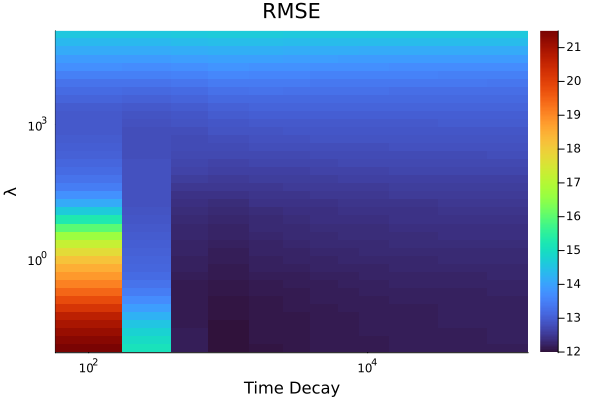

In [98]:
p1 = Plots.heatmap(decays, λs, rmse_results, 
              xlabel="Time Decay", ylabel="λ", 
              title="RMSE", 
              yscale=:log10, xscale=:log10, # On utilise une échelle log pour mieux visualiser les différences
              color=:turbo)

On voit que les valeurs trouvées sont cohérentes dans l'espace des paramètres (à gauche)

## 9. Entraînement Final et Prédictions

### Entraînement Périodique 

L’adoption d’une approche segmentée par saison repose sur le constat que la relation entre les variables explicatives et la cible n'est pas stationnaire au cours de l'année. 

En hiver, les pics de pollution sont souvent liés à des phénomènes d'inversion thermique et au chauffage résidentiel. En été, ils sont dominés par la photochimie (que nous avons tenté de faire rentrer dans les variables explicatives précédemment) et les réactions liées au rayonnement UV. 

Un modèle global ferait la moyenne de ces coefficients, perdant ainsi en précision lors des événements extrêmes propres à chaque saison.

En entraînant quatre modèles distincts, on permet au vecteur $\beta$ d'évoluer. Par exemple, le coefficient associé à la température peut être positif en été et négatif en hiver.

Mathématiquement, cela revient à traiter la saison comme une variable d'interaction globale. Cette segmentation réduit l'erreur systématique du modèle en lui permettant d'ajuster sa structure interne à la saisonnalité.

On pourrait alors penser que, les saisons étant une invention humaine, la vraie distribution ne répondrait pas à une telle démarcation. Nous avons essayé d'expérimenter une validation croisée pour un nombre $n$ de saisons variables. Nous avons obtenu un optimum de $n=9$, ce qui réduisait beaucoup trop la taille de nos échantillons et produisait du sur-apprentissage.

Nous effectuons donc une itération sur les quatre saisons. 

Pour chaque saison :
1. Nous isolons les échantillons
2. Nous appliquons le *decay* calculé précédemment
3. Nous standardisons l'ensemble d'entraînement et validation par rapport aux statistiques de l'entraînement
4. Nous résolvons la forme fermée de la régression ridge afin de déterminer les coefficients optimaux.

In [99]:
y_target = Float64.(df_train.PM_max)

for s in 1:4
    idx_tr = findall(df_train.season .== s)
    train_s = df_train[idx_tr, :]
    test_s = filter(:season => ==(s), df_test)
    if nrow(test_s) == 0; continue; end
    
    X_tr = Matrix(train_s[:, features]) .|> Float64
    y_tr = y_target[idx_tr]
    X_te = Matrix(test_s[:, features]) .|> Float64
    
    # Decay 
    w_vec = exp.(-days_diff_train[idx_tr] ./ best_decay)
    w_vec ./= mean(w_vec)
    W = Diagonal(w_vec)
    
    μ = mean(X_tr, dims=1)
    σ = std(X_tr, dims=1)
    σ[σ .== 0] .= 1.0
    
    X_tr_n = (X_tr .- μ) ./ σ
    X_te_n = (X_te .- μ) ./ σ
    n = size(X_tr_n, 1)
    X_ext = hcat(ones(n), X_tr_n)
    I_ext = Matrix{Float64}(I, size(X_ext, 2), size(X_ext, 2))
    I_ext[1, 1] = 0.0
    
    β_s = (X_ext' * W * X_ext + best_λ * I_ext) \ (X_ext' * W * y_tr)
    ŷ = hcat(ones(size(X_te_n, 1)), X_te_n) * β_s
    
    test_idx = findall(df_test.season .== s)
    # On clamp la valeur max à 250.0 pour être cohérent avec les clamping précédents
    df_test[test_idx, :PM] = clamp.(ŷ, 0.0, 250.0)
end


### Génération du fichier de soumission

Nous formattons nos prédictions finales dans un DataFrame pour enregistrer le fichier `soumission.csv` destiné à être testé pour la compétition Kaggle.

In [100]:

out_csv = "soumission.csv"
submission = DataFrame(ID = ["(Date(\"$(first(string(d), 10))\"), $s)" for (d, s) in zip(df_test.Date, df_test.stationId)], PM=df_test.PM)
CSV.write(out_csv, submission)
println("done, fichier soumission exporté : $out_csv")

done, fichier soumission exporté : soumission.csv


### Conclusion Graphique 

Le graphique de densité confirme la stabilité  du modèle: les prédictions restent dans des intervalles physiquement cohérents sans dérive numérique (absence de valeurs négatives ou d'explosions à l'infini)

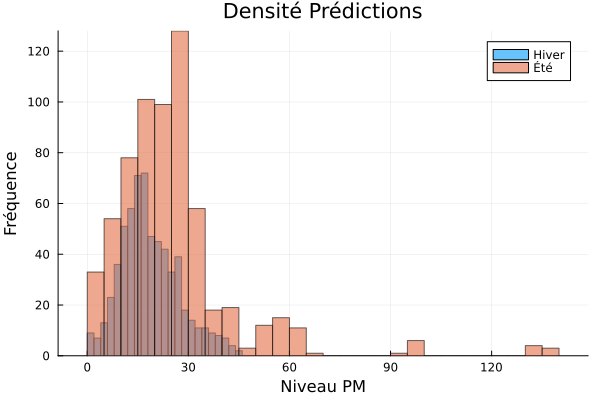

In [101]:
h1 = histogram(df_test.PM[df_test.season .== 1], bins=40, alpha=0.6, label="Hiver", 
               title="Densité Prédictions", xlabel="Niveau PM", ylabel="Fréquence")
histogram!(h1, df_test.PM[df_test.season .== 3], bins=40, alpha=0.6, label="Été")
display(h1)

## 10. Conclusion

### Résultats obtenus

| Modèle | Description | 
| :--- | :--- |
| Naïf (baseline) | Moyenne globale de PM 
| Modèle 1 — Ridge par station | Ridge + BIC-Gibbs + lags 
| Modèle 2 — Ridge global | Ridge + log(1+PM)
| Modèle 3 — Mélange bayésien | Classifieur naïf + 2 ridge 
| **Modèle final** — Ridge saisonnier | Ridge × 4 saisons + ingénierie des variables 

Le modèle final retenu repose sur quatre régressions ridge entraînées séparément par saison, avec pondération exponentielle des observations récentes et une matrice de variables explicatives enrichie (transformations non-linéaires, interactions saisonnières et spatiales).


In [102]:
println("Modèle naïf    : ", round(rmse_naif,    digits=4))
println("Modèle 1       : ", round(rmse_modele1, digits=4))
println("Modèle 2       : ", round(rmse_modele2, digits=4))
println("Modèle 3       : ", round(rmse_m3_val,  digits=4))
println("Modèle final   : ", round(best_rmse,    digits=4))

UndefVarError: UndefVarError: `rmse_naif` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Limites identifiées

1. **Les pics extrêmes liés aux feux de forêt** (PM > 100) restent difficiles à prédire. Le modèle ne dispose d'aucun signal sur l'origine distante de la fumée, et les variables météorologiques locales ne suffisent pas à anticiper ces épisodes.

2. **La dérive temporelle** : le modèle est entraîné sur 2007–2024, mais les conditions climatiques de 2025 peuvent s'écarter de cet historique. La pondération exponentielle atténue partiellement ce problème.

### Perspectives d'amélioration

- Intégrer des données de feux actifs comme variable explicative pour les épisodes extrêmes.
- Explorer des modèles non-linéaires (forêts aléatoires, gradient boosting) tout en maintenant une interprétabilité suffisante.
- Affiner la saisonnalité avec un nombre de segments plus élevé si la taille des échantillons le permet (au cas où nous aurions plus de données).

# Références

[^1] Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research.

[^2]Seinfeld, J. H., & Pandis, S. N. (2016). Atmospheric chemistry and physics: From air pollution to climate change (3rd ed.). John Wiley & Sons.

[^3] https://www.airnow.gov/aqi/aqi-basics/

[^4]: Seinfeld, J. H., & Pandis, S. N. (2016). *Atmospheric Chemistry and Physics: From Air Pollution to Climate Change* (3rd ed.). John Wiley & Sons.